# Notebook 06 — Final Model Comparison and Business Interpretation

## Purpose

This is the final analytical notebook in the dissertation pipeline.

It combines two previously separate stages:

1. **Frozen K-Means K=5 versus frozen GMM C5 Spherical comparison**
2. **Aligned profile interpretation, business strategy mapping and final model decision**

No clustering model is retrained in this notebook.

The notebook uses the frozen outputs from:

- **Notebook 03 — Final K-Means K=5 and Customer Confidence**
- **Notebook 04 — GMM Evaluation and Model Selection**
- **Notebook 05 — Final GMM C5 Spherical and Membership Evidence**

The workflow is:

- verify that both models use the same 4,338 customers and seven behavioural features;
- compare only technically comparable validation and stability metrics;
- compare the complete unlabelled partitions using ARI and NMI;
- align arbitrary GMM component numbers to K-Means clusters using Hungarian maximum-overlap mapping;
- quantify customer agreement and movement;
- compare K-Means boundary evidence with GMM probability-based ambiguity;
- compare original-scale aligned customer profiles;
- assign defensible business interpretations to the aligned GMM groups;
- build the final business strategy mapping;
- retain **K-Means K=5 as the primary operational model**;
- retain **GMM C5 Spherical as the supporting probabilistic model**;
- export the final dashboard-ready customer and strategy datasets.

> **Important:** Aligned agreement is not classification accuracy. Neither model has ground-truth customer class labels.


## Important comparison rules

### Metrics that can be compared directly

Because the two frozen models use the same customer population and the same seven processed behavioural features, the following evidence can be compared:

- Silhouette Score;
- Davies–Bouldin Index;
- Calinski–Harabasz Index;
- random-seed ARI;
- repeated 80% subsampling ARI;
- smallest group percentage.

### Metrics that remain model-specific

Do **not** compare these as if they were the same objective:

- K-Means WCSS / inertia;
- GMM AIC;
- GMM BIC.

### Customer-confidence evidence is complementary

K-Means confidence is based mainly on geometric boundary evidence.

GMM confidence is based mainly on posterior-probability concentration.

Their review flags therefore measure different uncertainty dimensions.


## 1. Import libraries


In [65]:
import os
import json
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import euclidean, pdist
from scipy.stats import spearmanr

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    cohen_kappa_score
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_style("whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Configure final input archives and output folders

Upload the final ZIP outputs from Notebooks 03, 04 and 05.

The code accepts the normal filenames and also tolerates duplicate-browser suffixes such as `(1)`.


In [66]:
# ------------------------------------------------------------
# Runtime root
# ------------------------------------------------------------

CONTENT_DIR = Path("/content")
SANDBOX_DIR = Path("/mnt/data")

if CONTENT_DIR.exists():
    DEFAULT_ROOT = CONTENT_DIR
else:
    DEFAULT_ROOT = SANDBOX_DIR


def locate_zip(preferred_name, keyword):
    """
    Locate an input ZIP in /content first, then /mnt/data.
    The keyword fallback supports browser-renamed copies such as (1).
    """
    search_roots = [CONTENT_DIR, SANDBOX_DIR]

    for root in search_roots:
        exact = root / preferred_name
        if exact.exists():
            return exact

    for root in search_roots:
        if not root.exists():
            continue

        candidates = sorted(
            [
                path
                for path in root.glob("*.zip")
                if keyword.lower() in path.name.lower()
            ]
        )

        if candidates:
            return candidates[0]

    raise FileNotFoundError(
        f"Could not locate required ZIP: {preferred_name}"
    )


NOTEBOOK03_ZIP = locate_zip(
    "03_Final_KMeans_K5_and_Confidence_All_Results.zip",
    "03_Final_KMeans_K5_and_Confidence_All_Results"
)

NOTEBOOK04_ZIP = locate_zip(
    "04_GMM_Evaluation_and_Model_Selection_All_Results.zip",
    "04_GMM_Evaluation_and_Model_Selection_All_Results"
)

NOTEBOOK05_ZIP = locate_zip(
    "05_Final_GMM_C5_Spherical_and_Membership_All_Results.zip",
    "05_Final_GMM_C5_Spherical_and_Membership_All_Results"
)

# Use the same root as Notebook 03 for outputs.
BASE_DIR = NOTEBOOK03_ZIP.parent

SOURCE_ROOT = (
    BASE_DIR
    / "Notebook06_Source_Archives"
)

KMEANS_SOURCE_DIR = SOURCE_ROOT / "Notebook03"
GMM_SELECTION_SOURCE_DIR = SOURCE_ROOT / "Notebook04"
GMM_MEMBERSHIP_SOURCE_DIR = SOURCE_ROOT / "Notebook05"

RESULTS_DIR = (
    BASE_DIR
    / "06_Final_Model_Comparison_and_Business_Interpretation_Results"
)

TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
DATASETS_DIR = RESULTS_DIR / "Datasets"
ALIGNMENT_DIR = RESULTS_DIR / "Alignment"
PROFILES_DIR = RESULTS_DIR / "Profiles"
STRATEGY_DIR = RESULTS_DIR / "Strategy"
DECISION_DIR = RESULTS_DIR / "Decision"
QUALITY_DIR = RESULTS_DIR / "Quality_Checks"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    DATASETS_DIR,
    ALIGNMENT_DIR,
    PROFILES_DIR,
    STRATEGY_DIR,
    DECISION_DIR,
    QUALITY_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

EXPECTED_CUSTOMERS = 4338
EXPECTED_GROUPS = 5

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

print("Notebook 03 ZIP:", NOTEBOOK03_ZIP)
print("Notebook 04 ZIP:", NOTEBOOK04_ZIP)
print("Notebook 05 ZIP:", NOTEBOOK05_ZIP)
print("Notebook 06 output:", RESULTS_DIR)


Notebook 03 ZIP: /content/03_Final_KMeans_K5_and_Confidence_All_Results.zip
Notebook 04 ZIP: /content/04_GMM_Evaluation_and_Model_Selection_All_Results.zip
Notebook 05 ZIP: /content/05_Final_GMM_C5_Spherical_and_Membership_All_Results.zip
Notebook 06 output: /content/06_Final_Model_Comparison_and_Business_Interpretation_Results


## 3. Extract the frozen source archives and locate required outputs

In [67]:
def extract_clean(zip_path, destination):
    if destination.exists():
        shutil.rmtree(destination)

    destination.mkdir(
        parents=True,
        exist_ok=True
    )

    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(destination)


def find_unique_file(search_root, file_name):
    matches = list(
        Path(search_root).rglob(file_name)
    )

    if not matches:
        raise FileNotFoundError(
            f"Could not locate '{file_name}' under {search_root}."
        )

    if len(matches) > 1:
        print(
            f"Multiple matches found for {file_name}; "
            f"using {matches[0]}"
        )

    return matches[0]


if SOURCE_ROOT.exists():
    shutil.rmtree(SOURCE_ROOT)

extract_clean(
    NOTEBOOK03_ZIP,
    KMEANS_SOURCE_DIR
)

extract_clean(
    NOTEBOOK04_ZIP,
    GMM_SELECTION_SOURCE_DIR
)

extract_clean(
    NOTEBOOK05_ZIP,
    GMM_MEMBERSHIP_SOURCE_DIR
)

# Notebook 03
KMEANS_VALIDATION_FILE = find_unique_file(
    KMEANS_SOURCE_DIR,
    "final_kmeans_validation_metrics.csv"
)

KMEANS_SEED_SUMMARY_FILE = find_unique_file(
    KMEANS_SOURCE_DIR,
    "final_k5_random_seed_summary.csv"
)

KMEANS_SUBSAMPLE_SUMMARY_FILE = find_unique_file(
    KMEANS_SOURCE_DIR,
    "final_k5_subsampling_summary.csv"
)

KMEANS_CLUSTER_SIZES_FILE = find_unique_file(
    KMEANS_SOURCE_DIR,
    "final_cluster_size_with_names.csv"
)

KMEANS_CONFIDENCE_SUMMARY_FILE = find_unique_file(
    KMEANS_SOURCE_DIR,
    "customer_assignment_confidence_summary.csv"
)

KMEANS_CUSTOMERS_FILE = find_unique_file(
    KMEANS_SOURCE_DIR,
    "customer_cluster_assignment_confidence.csv"
)

# Notebook 04
GMM_SELECTED_EVIDENCE_FILE = find_unique_file(
    GMM_SELECTION_SOURCE_DIR,
    "final_gmm_c5_selected_evidence.csv"
)

GMM_COMPONENT_SIZES_FILE = find_unique_file(
    GMM_SELECTION_SOURCE_DIR,
    "final_gmm_c5_component_sizes.csv"
)

# Notebook 05
GMM_MEMBERSHIP_DATA_FILE = find_unique_file(
    GMM_MEMBERSHIP_SOURCE_DIR,
    "final_gmm_customer_membership_analysis.csv"
)

GMM_CONFIDENCE_SUMMARY_FILE = find_unique_file(
    GMM_MEMBERSHIP_SOURCE_DIR,
    "gmm_membership_confidence_summary.csv"
)

GMM_CONDITION_SUMMARY_FILE = find_unique_file(
    GMM_MEMBERSHIP_SOURCE_DIR,
    "gmm_membership_condition_summary.csv"
)

located_files = pd.DataFrame({
    "Required_Output": [
        "K-Means validation metrics",
        "K-Means seed stability",
        "K-Means subsampling stability",
        "K-Means cluster sizes",
        "K-Means confidence summary",
        "K-Means customer confidence data",
        "GMM selected evidence",
        "GMM component sizes",
        "GMM customer membership data",
        "GMM confidence summary",
        "GMM condition summary"
    ],
    "File_Path": [
        KMEANS_VALIDATION_FILE,
        KMEANS_SEED_SUMMARY_FILE,
        KMEANS_SUBSAMPLE_SUMMARY_FILE,
        KMEANS_CLUSTER_SIZES_FILE,
        KMEANS_CONFIDENCE_SUMMARY_FILE,
        KMEANS_CUSTOMERS_FILE,
        GMM_SELECTED_EVIDENCE_FILE,
        GMM_COMPONENT_SIZES_FILE,
        GMM_MEMBERSHIP_DATA_FILE,
        GMM_CONFIDENCE_SUMMARY_FILE,
        GMM_CONDITION_SUMMARY_FILE
    ]
})

display(located_files)


,Required_Output,File_Path
0,K-Means validation metrics,/content/Notebook06_Source_Archives/Notebook03...
1,K-Means seed stability,/content/Notebook06_Source_Archives/Notebook03...
2,K-Means subsampling stability,/content/Notebook06_Source_Archives/Notebook03...
3,K-Means cluster sizes,/content/Notebook06_Source_Archives/Notebook03...
4,K-Means confidence summary,/content/Notebook06_Source_Archives/Notebook03...
5,K-Means customer confidence data,/content/Notebook06_Source_Archives/Notebook03...
6,GMM selected evidence,/content/Notebook06_Source_Archives/Notebook04...
7,GMM component sizes,/content/Notebook06_Source_Archives/Notebook04...
8,GMM customer membership data,/content/Notebook06_Source_Archives/Notebook05...
9,GMM confidence summary,/content/Notebook06_Source_Archives/Notebook05...


## 4. Load the frozen K-Means and GMM evidence

Notebook 03 stores final K-Means validation and stability in separate tables. This cell combines them into one frozen K-Means evidence record so that the final comparison is explicit and reproducible.


In [68]:
kmeans_validation = pd.read_csv(
    KMEANS_VALIDATION_FILE
)

kmeans_seed_summary = pd.read_csv(
    KMEANS_SEED_SUMMARY_FILE
)

kmeans_subsample_summary = pd.read_csv(
    KMEANS_SUBSAMPLE_SUMMARY_FILE
)

kmeans_cluster_sizes = pd.read_csv(
    KMEANS_CLUSTER_SIZES_FILE
)

kmeans_confidence_summary = pd.read_csv(
    KMEANS_CONFIDENCE_SUMMARY_FILE
)

kmeans_customers = pd.read_csv(
    KMEANS_CUSTOMERS_FILE
)

gmm_selected_evidence = pd.read_csv(
    GMM_SELECTED_EVIDENCE_FILE
)

gmm_component_sizes = pd.read_csv(
    GMM_COMPONENT_SIZES_FILE
)

gmm_membership_data = pd.read_csv(
    GMM_MEMBERSHIP_DATA_FILE
)

gmm_confidence_summary = pd.read_csv(
    GMM_CONFIDENCE_SUMMARY_FILE
)

gmm_condition_summary = pd.read_csv(
    GMM_CONDITION_SUMMARY_FILE
)


def metric_lookup(table, metric_name):
    return float(
        table.loc[
            table["Metric"] == metric_name,
            "Value"
        ].iloc[0]
    )


kmeans_metrics = pd.DataFrame([{
    "Silhouette_Score": metric_lookup(
        kmeans_validation,
        "Silhouette Score"
    ),
    "Davies_Bouldin_Index": metric_lookup(
        kmeans_validation,
        "Davies-Bouldin Index"
    ),
    "Calinski_Harabasz_Index": metric_lookup(
        kmeans_validation,
        "Calinski-Harabasz Index"
    ),
    "WCSS_Inertia": metric_lookup(
        kmeans_validation,
        "WCSS / Inertia"
    ),
    "Mean_Random_Seed_ARI": metric_lookup(
        kmeans_seed_summary,
        "Mean ARI"
    ),
    "Minimum_Random_Seed_ARI": metric_lookup(
        kmeans_seed_summary,
        "Minimum ARI"
    ),
    "Mean_Subsampling_ARI": metric_lookup(
        kmeans_subsample_summary,
        "Mean ARI"
    ),
    "Minimum_Subsampling_ARI": metric_lookup(
        kmeans_subsample_summary,
        "Minimum ARI"
    ),
    "Smallest_Cluster_Percentage": float(
        kmeans_cluster_sizes[
            "Customer_Percentage"
        ].min()
    )
}])

print("K-Means customer rows:", len(kmeans_customers))
print("GMM customer rows:", len(gmm_membership_data))

display(kmeans_metrics)
display(gmm_selected_evidence)


K-Means customer rows: 4338
GMM customer rows: 4338


,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,WCSS_Inertia,Mean_Random_Seed_ARI,Minimum_Random_Seed_ARI,Mean_Subsampling_ARI,Minimum_Subsampling_ARI,Smallest_Cluster_Percentage
0,0.2512,1.2230,"1,755.9685","6,866.0351",0.9999,0.9996,0.9541,0.9011,11.9900


,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Negative_Silhouette_Count,Negative_Silhouette_Percentage,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,All_Components_At_Least_5_Percent,Minimum_Covariance_Value,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Median_Normalised_Entropy,Requested_Runs_Seed,Successful_Runs_Seed,Convergence_Rate_Seed,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_AIC_Across_Seeds,Mean_BIC_Across_Seeds,Requested_Runs_Subsample,Successful_Runs_Subsample,Sample_Size,Sample_Fraction,Convergence_Rate_Subsample,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation,Mean_Smallest_Sample_Component_Percentage,Minimum_Smallest_Sample_Component_Percentage,Passes_Component_Feasibility,Passes_Seed_Stability,Passes_Subsampling_Stability,Passes_Operational_Gates
0,GMM_C5_spherical,5,spherical,True,11,0.9737,-5.8326,-5.8329,"50,691.2165","50,971.7240",0.2299,628,14.4767,1.3749,"1,587.4952",494,11.3877,37.0678,True,0.1421,0.9221,0.9908,227,5.2328,0.8503,0.9827,194,4.4721,0.1201,0.0338,30,30,1.0000,0.9985,0.9992,0.9918,1.0000,0.0020,"50,691.2220","50,971.7294",50,50,3470,0.8000,1.0000,0.9610,0.9660,0.8898,0.9879,0.0202,11.4259,10.7781,True,True,True,True


# Phase A — Frozen K-Means K=5 versus GMM C5 Spherical

This phase compares the two frozen partitions technically and at customer level before any final business-model decision is made.


## A1. Validate the common customer population and feature values

The comparison is allowed to proceed only when:

- both datasets contain 4,338 unique CustomerID values;
- the CustomerID sets are identical;
- all seven original-scale customer features agree after alignment;
- both models contain five populated groups.

In [69]:
for model_name, customer_data in {
    "K-Means": kmeans_customers,
    "GMM": gmm_membership_data
}.items():

    if len(customer_data) != EXPECTED_CUSTOMERS:
        raise ValueError(
            f"{model_name} does not contain "
            f"{EXPECTED_CUSTOMERS:,} customers."
        )

    if not customer_data[
        "CustomerID"
    ].is_unique:
        raise ValueError(
            f"{model_name} contains duplicate CustomerID values."
        )

missing_kmeans_columns = [
    column
    for column in [
        "CustomerID",
        "Cluster",
        "Segment_Name",
        "Silhouette_Value",
        "Combined_Boundary_Flag",
        "Assignment_Confidence_Category"
    ] + FEATURE_COLUMNS
    if column not in kmeans_customers.columns
]

missing_gmm_columns = [
    column
    for column in [
        "CustomerID",
        "GMM_Component",
        "Silhouette_Value",
        "Combined_Ambiguous_Flag",
        "Membership_Confidence_Category",
        "Maximum_Probability",
        "Probability_Margin",
        "Normalised_Entropy"
    ] + FEATURE_COLUMNS
    if column not in gmm_membership_data.columns
]

if missing_kmeans_columns:
    raise ValueError(
        "Missing K-Means columns: "
        f"{missing_kmeans_columns}"
    )

if missing_gmm_columns:
    raise ValueError(
        "Missing GMM columns: "
        f"{missing_gmm_columns}"
    )

common_customer_ids = set(
    kmeans_customers[
        "CustomerID"
    ]
)

if common_customer_ids != set(
    gmm_membership_data[
        "CustomerID"
    ]
):
    raise ValueError(
        "The two models do not contain the same CustomerID set."
    )

comparison_features = (
    kmeans_customers[
        [
            "CustomerID"
        ] + FEATURE_COLUMNS
    ]
    .merge(
        gmm_membership_data[
            [
                "CustomerID"
            ] + FEATURE_COLUMNS
        ],
        on="CustomerID",
        how="inner",
        suffixes=(
            "_KMeans",
            "_GMM"
        ),
        validate="one_to_one"
    )
)

feature_mismatches = []

for feature in FEATURE_COLUMNS:

    kmeans_values = comparison_features[
        f"{feature}_KMeans"
    ].to_numpy()

    gmm_values = comparison_features[
        f"{feature}_GMM"
    ].to_numpy()

    if not np.allclose(
        kmeans_values,
        gmm_values,
        equal_nan=True
    ):
        feature_mismatches.append(
            feature
        )

if feature_mismatches:
    raise ValueError(
        "Original-scale features differ between frozen "
        f"outputs: {feature_mismatches}"
    )

if kmeans_customers[
    "Cluster"
].nunique() != EXPECTED_GROUPS:
    raise ValueError(
        "K-Means does not contain five clusters."
    )

if gmm_membership_data[
    "GMM_Component"
].nunique() != EXPECTED_GROUPS:
    raise ValueError(
        "GMM does not contain five components."
    )

print("=" * 80)
print("COMMON COMPARISON POPULATION VALIDATED")
print("=" * 80)

print("Customers:", EXPECTED_CUSTOMERS)
print("Features:", len(FEATURE_COLUMNS))
print("Groups per model:", EXPECTED_GROUPS)

COMMON COMPARISON POPULATION VALIDATED
Customers: 4338
Features: 7
Groups per model: 5


## A2. Create the customer-level cross-model comparison dataset


In [70]:
kmeans_comparison_columns = [
    "CustomerID",
    *FEATURE_COLUMNS,
    "Cluster",
    "Segment_Name",
    "Alternative_Cluster",
    "Alternative_Segment",
    "Silhouette_Value",
    "Relative_Centroid_Margin",
    "Combined_Boundary_Flag",
    "Assignment_Confidence_Category"
]

gmm_comparison_columns = [
    "CustomerID",
    "GMM_Component",
    "Alternative_GMM_Component",
    "Maximum_Probability",
    "Second_Probability",
    "Probability_Margin",
    "Normalised_Entropy",
    "Silhouette_Value",
    "Combined_Ambiguous_Flag",
    "Membership_Confidence_Category"
]

customer_model_comparison = (
    kmeans_customers[
        kmeans_comparison_columns
    ]
    .merge(
        gmm_membership_data[
            gmm_comparison_columns
        ],
        on="CustomerID",
        how="inner",
        suffixes=(
            "_KMeans",
            "_GMM"
        ),
        validate="one_to_one"
    )
)

customer_model_comparison = (
    customer_model_comparison
    .sort_values(
        "CustomerID"
    )
    .reset_index(drop=True)
)

display(
    customer_model_comparison.head()
)

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,Cluster,Segment_Name,Alternative_Cluster,Alternative_Segment,Silhouette_Value_KMeans,Relative_Centroid_Margin,Combined_Boundary_Flag,Assignment_Confidence_Category,GMM_Component,Alternative_GMM_Component,Maximum_Probability,Second_Probability,Probability_Margin,Normalised_Entropy,Silhouette_Value_GMM,Combined_Ambiguous_Flag,Membership_Confidence_Category
0,12346,326,1,"77,183.6000","77,183.6000","74,215.0000",1,74215,4,High-Value Large-Order Buyers,2,High-Value Loyal Customers,0.0884,0.0918,True,Boundary / Ambiguous Assignment,1,4,1.0000,0.0000,1.0000,0.0000,0.1461,False,Strong Membership
1,12347,2,7,"4,310.0000",615.7100,351.1400,103,2458,2,High-Value Loyal Customers,4,High-Value Large-Order Buyers,0.3445,0.5655,False,Strong Assignment,2,1,0.9751,0.0249,0.9502,0.0724,0.4080,False,Strong Membership
2,12348,75,4,"1,797.2400",449.3100,585.2500,22,2341,4,High-Value Large-Order Buyers,2,High-Value Loyal Customers,0.1586,0.3510,False,Moderate Assignment,1,2,0.8729,0.1229,0.7500,0.2480,-0.1604,False,Strong Membership
3,12349,19,1,"1,757.5500","1,757.5500",631.0000,73,631,4,High-Value Large-Order Buyers,2,High-Value Loyal Customers,0.3175,0.4503,False,Strong Assignment,1,2,1.0000,0.0000,1.0000,0.0000,0.1515,False,Strong Membership
4,12350,310,1,334.4000,334.4000,197.0000,17,197,0,Dormant Occasional Customers,1,Active Regular Customers,0.5066,0.7095,False,Strong Assignment,3,4,1.0000,0.0000,0.9999,0.0003,0.5486,False,Strong Membership


## A3. Compare common technical metrics

This table contains metrics that can be compared because both models use the
same customer matrix.

No equal-weight composite score is created.

In [71]:
kmeans_row = kmeans_metrics.iloc[0]
gmm_row = gmm_selected_evidence.iloc[0]

technical_metric_definitions = [
    (
        "Silhouette Score",
        "Silhouette_Score",
        "Silhouette_Score",
        "Higher",
        (
            "Cohesion and separation of hard "
            "customer assignments."
        )
    ),
    (
        "Davies-Bouldin Index",
        "Davies_Bouldin_Index",
        "Davies_Bouldin_Index",
        "Lower",
        (
            "Within-group dispersion relative to "
            "between-group separation."
        )
    ),
    (
        "Calinski-Harabasz Index",
        "Calinski_Harabasz_Index",
        "Calinski_Harabasz_Index",
        "Higher",
        (
            "Between-group variation relative to "
            "within-group variation."
        )
    ),
    (
        "Mean Random-Seed ARI",
        "Mean_Random_Seed_ARI",
        "Mean_Seed_ARI",
        "Higher",
        (
            "Average assignment consistency across "
            "different initial states."
        )
    ),
    (
        "Minimum Random-Seed ARI",
        "Minimum_Random_Seed_ARI",
        "Minimum_Seed_ARI",
        "Higher",
        (
            "Worst observed assignment consistency "
            "across initial states."
        )
    ),
    (
        "Mean 80% Subsampling ARI",
        "Mean_Subsampling_ARI",
        "Mean_Subsampling_ARI",
        "Higher",
        (
            "Average consistency when models are fitted "
            "to repeated 80% customer samples."
        )
    ),
    (
        "Minimum 80% Subsampling ARI",
        "Minimum_Subsampling_ARI",
        "Minimum_Subsampling_ARI",
        "Higher",
        (
            "Worst observed consistency across repeated "
            "80% customer samples."
        )
    ),
    (
        "Smallest Group Percentage",
        "Smallest_Cluster_Percentage",
        "Smallest_Component_Percentage",
        "Contextual",
        (
            "Practical size of the smallest customer group."
        )
    )
]

technical_comparison_rows = []

for (
    metric,
    kmeans_column,
    gmm_column,
    preferred_direction,
    definition
) in technical_metric_definitions:

    kmeans_value = float(
        kmeans_row[
            kmeans_column
        ]
    )

    gmm_value = float(
        gmm_row[
            gmm_column
        ]
    )

    if preferred_direction == "Higher":
        preferred_model = (
            "K-Means K=5"
            if kmeans_value > gmm_value
            else "GMM C5 Spherical"
        )
    elif preferred_direction == "Lower":
        preferred_model = (
            "K-Means K=5"
            if kmeans_value < gmm_value
            else "GMM C5 Spherical"
        )
    else:
        preferred_model = (
            "No automatic winner"
        )

    technical_comparison_rows.append({
        "Metric": metric,
        "Definition": definition,
        "Preferred_Direction": preferred_direction,
        "KMeans_K5": kmeans_value,
        "GMM_C5_Spherical": gmm_value,
        "Metric_Preference": preferred_model
    })

technical_comparison = (
    pd.DataFrame(
        technical_comparison_rows
    )
    .round(6)
)

display(technical_comparison)

technical_comparison.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_common_technical_metrics.csv",
    index=False
)

,Metric,Definition,Preferred_Direction,KMeans_K5,GMM_C5_Spherical,Metric_Preference
0,Silhouette Score,Cohesion and separation of hard customer assig...,Higher,0.2512,0.2299,K-Means K=5
1,Davies-Bouldin Index,Within-group dispersion relative to between-gr...,Lower,1.2230,1.3749,K-Means K=5
2,Calinski-Harabasz Index,Between-group variation relative to within-gro...,Higher,"1,755.9685","1,587.4952",K-Means K=5
3,Mean Random-Seed ARI,Average assignment consistency across differen...,Higher,0.9999,0.9985,K-Means K=5
4,Minimum Random-Seed ARI,Worst observed assignment consistency across i...,Higher,0.9996,0.9918,K-Means K=5
5,Mean 80% Subsampling ARI,Average consistency when models are fitted to ...,Higher,0.9541,0.9610,GMM C5 Spherical
6,Minimum 80% Subsampling ARI,Worst observed consistency across repeated 80%...,Higher,0.9011,0.8898,K-Means K=5
7,Smallest Group Percentage,Practical size of the smallest customer group.,Contextual,11.9900,11.3877,No automatic winner


## A4. Record model-specific objective metrics separately

These values support each model's own analysis but are not compared as though
they measure the same objective.

In [72]:
model_specific_metrics = pd.DataFrame({
    "Model": [
        "K-Means K=5",
        "GMM C5 Spherical",
        "GMM C5 Spherical"
    ],
    "Metric": [
        "WCSS / Inertia",
        "AIC",
        "BIC"
    ],
    "Value": [
        float(
            kmeans_row[
                "WCSS_Inertia"
            ]
        ),
        float(
            gmm_row[
                "AIC"
            ]
        ),
        float(
            gmm_row[
                "BIC"
            ]
        )
    ],
    "Interpretation": [
        (
            "K-Means within-cluster squared-distance "
            "objective. Lower only within comparable "
            "K-Means configurations."
        ),
        (
            "GMM likelihood fit with a complexity penalty. "
            "Lower only within GMM configurations."
        ),
        (
            "GMM likelihood fit with a stronger complexity "
            "penalty. Lower only within GMM configurations."
        )
    ]
})

display(model_specific_metrics)

model_specific_metrics.to_csv(
    TABLES_DIR
    / "model_specific_objective_metrics.csv",
    index=False
)

,Model,Metric,Value,Interpretation
0,K-Means K=5,WCSS / Inertia,"6,866.0351",K-Means within-cluster squared-distance object...
1,GMM C5 Spherical,AIC,"50,691.2165",GMM likelihood fit with a complexity penalty. ...
2,GMM C5 Spherical,BIC,"50,971.7240",GMM likelihood fit with a stronger complexity ...


## A5. Measure overall partition agreement

ARI and NMI compare the two partitions without requiring component-number
alignment.

They measure structural agreement, not which model is correct.

In [73]:
kmeans_labels = (
    customer_model_comparison[
        "Cluster"
    ]
    .astype(int)
    .to_numpy()
)

gmm_labels = (
    customer_model_comparison[
        "GMM_Component"
    ]
    .astype(int)
    .to_numpy()
)

cross_model_ari = adjusted_rand_score(
    kmeans_labels,
    gmm_labels
)

cross_model_nmi = (
    normalized_mutual_info_score(
        kmeans_labels,
        gmm_labels
    )
)

raw_assignment_matrix = pd.crosstab(
    pd.Series(
        kmeans_labels,
        name="KMeans_Cluster"
    ),
    pd.Series(
        gmm_labels,
        name="GMM_Component"
    )
).reindex(
    index=range(EXPECTED_GROUPS),
    columns=range(EXPECTED_GROUPS),
    fill_value=0
)

agreement_summary = pd.DataFrame({
    "Agreement_Measure": [
        "Adjusted Rand Index",
        "Normalised Mutual Information"
    ],
    "Value": [
        cross_model_ari,
        cross_model_nmi
    ],
    "Interpretation": [
        (
            "Agreement between complete customer "
            "partitions, adjusted for chance."
        ),
        (
            "Shared assignment information between "
            "the two partitions."
        )
    ]
})

display(agreement_summary)
display(raw_assignment_matrix)

agreement_summary.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_assignment_agreement.csv",
    index=False
)

raw_assignment_matrix.to_csv(
    ALIGNMENT_DIR
    / "kmeans_vs_gmm_raw_assignment_matrix.csv"
)

,Agreement_Measure,Value,Interpretation
0,Adjusted Rand Index,0.6289,Agreement between complete customer partitions...
1,Normalised Mutual Information,0.6512,Shared assignment information between the two ...


GMM_Component,0,1,2,3,4
KMeans_Cluster,,,,,
0,49,7,0,514,91
1,1312,1,61,0,80
2,0,147,846,0,0
3,0,0,0,0,520
4,247,339,110,14,0


## A6. Align GMM components to K-Means clusters by maximum overlap

Component labels are arbitrary. For example, K-Means Cluster 2 and GMM
Component 2 are not automatically the same behavioural group.

The Hungarian assignment algorithm finds a one-to-one mapping that maximises
the number of customers on the aligned diagonal.

This alignment is used only for:

- customer movement analysis;
- agreement percentages;
- later profile review.

It does not prove that the mapped groups have identical business meaning.

In [74]:
overlap_array = (
    raw_assignment_matrix.to_numpy()
)

row_indices, column_indices = (
    linear_sum_assignment(
        -overlap_array
    )
)

gmm_to_kmeans_mapping = {
    int(gmm_component): int(
        kmeans_cluster
    )
    for (
        kmeans_cluster,
        gmm_component
    ) in zip(
        row_indices,
        column_indices
    )
}

aligned_gmm_labels = np.array([
    gmm_to_kmeans_mapping[
        int(component)
    ]
    for component in gmm_labels
])

customer_model_comparison[
    "Aligned_GMM_Cluster"
] = aligned_gmm_labels

customer_model_comparison[
    "Models_Agree_After_Alignment"
] = (
    customer_model_comparison[
        "Cluster"
    ]
    == customer_model_comparison[
        "Aligned_GMM_Cluster"
    ]
)

aligned_assignment_matrix = pd.crosstab(
    customer_model_comparison[
        "Cluster"
    ],
    customer_model_comparison[
        "Aligned_GMM_Cluster"
    ],
    margins=True,
    margins_name="Total"
)

aligned_exact_agreement = float(
    customer_model_comparison[
        "Models_Agree_After_Alignment"
    ].mean()
)

alignment_mapping = pd.DataFrame({
    "Original_GMM_Component": list(
        gmm_to_kmeans_mapping.keys()
    ),
    "Aligned_KMeans_Cluster": list(
        gmm_to_kmeans_mapping.values()
    )
}).sort_values(
    "Aligned_KMeans_Cluster"
)

alignment_summary = pd.DataFrame({
    "Measure": [
        "ARI before alignment",
        "NMI before alignment",
        "Exact agreement after alignment"
    ],
    "Value": [
        cross_model_ari,
        cross_model_nmi,
        aligned_exact_agreement
    ]
})

display(alignment_mapping)
display(alignment_summary)
display(aligned_assignment_matrix)

alignment_mapping.to_csv(
    ALIGNMENT_DIR
    / "gmm_to_kmeans_overlap_alignment.csv",
    index=False
)

alignment_summary.to_csv(
    ALIGNMENT_DIR
    / "alignment_agreement_summary.csv",
    index=False
)

aligned_assignment_matrix.to_csv(
    ALIGNMENT_DIR
    / "kmeans_vs_aligned_gmm_assignment_matrix.csv"
)

,Original_GMM_Component,Aligned_KMeans_Cluster
0,3,0
1,0,1
2,2,2
3,4,3
4,1,4


,Measure,Value
0,ARI before alignment,0.6289
1,NMI before alignment,0.6512
2,Exact agreement after alignment,0.8140


Aligned_GMM_Cluster,0,1,2,3,4,Total
Cluster,,,,,,
0,514,49,0,91,7,661
1,0,1312,61,80,1,1454
2,0,0,846,0,147,993
3,0,0,0,520,0,520
4,14,247,110,0,339,710
Total,528,1608,1017,691,494,4338


## A7. Analyse customer retention and movement after alignment

For every K-Means segment, the notebook reports:

- customers remaining in the aligned GMM group;
- customers assigned to a different aligned GMM group;
- agreement percentage;
- the largest destination group among moved customers.

In [75]:
movement_rows = []

for cluster_number in sorted(
    customer_model_comparison[
        "Cluster"
    ].unique()
):

    cluster_data = (
        customer_model_comparison[
            customer_model_comparison[
                "Cluster"
            ] == cluster_number
        ]
    )

    agreed_data = cluster_data[
        cluster_data[
            "Models_Agree_After_Alignment"
        ]
    ]

    moved_data = cluster_data[
        ~cluster_data[
            "Models_Agree_After_Alignment"
        ]
    ]

    if len(moved_data) > 0:
        largest_destination = int(
            moved_data[
                "Aligned_GMM_Cluster"
            ]
            .value_counts()
            .idxmax()
        )

        largest_destination_count = int(
            moved_data[
                "Aligned_GMM_Cluster"
            ]
            .value_counts()
            .max()
        )
    else:
        largest_destination = np.nan
        largest_destination_count = 0

    movement_rows.append({
        "KMeans_Cluster": int(
            cluster_number
        ),
        "KMeans_Segment": (
            cluster_data[
                "Segment_Name"
            ].iloc[0]
        ),
        "Customer_Count": int(
            len(cluster_data)
        ),
        "Agreement_Count": int(
            len(agreed_data)
        ),
        "Agreement_Percentage": float(
            len(agreed_data)
            / len(cluster_data)
            * 100
        ),
        "Moved_Count": int(
            len(moved_data)
        ),
        "Moved_Percentage": float(
            len(moved_data)
            / len(cluster_data)
            * 100
        ),
        "Largest_Aligned_GMM_Destination": (
            largest_destination
        ),
        "Largest_Destination_Count": (
            largest_destination_count
        )
    })

movement_summary = (
    pd.DataFrame(
        movement_rows
    )
    .round(4)
)

movement_detail = (
    customer_model_comparison
    .groupby(
        [
            "Cluster",
            "Segment_Name",
            "Aligned_GMM_Cluster"
        ]
    )
    .size()
    .reset_index(
        name="Customer_Count"
    )
)

movement_detail[
    "Percentage_Within_KMeans_Segment"
] = (
    movement_detail[
        "Customer_Count"
    ]
    / movement_detail
    .groupby(
        [
            "Cluster",
            "Segment_Name"
        ]
    )[
        "Customer_Count"
    ]
    .transform("sum")
    * 100
)

movement_detail = (
    movement_detail
    .sort_values(
        [
            "Cluster",
            "Customer_Count"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(4)
)

display(movement_summary)
display(movement_detail)

movement_summary.to_csv(
    ALIGNMENT_DIR
    / "segment_level_model_agreement_summary.csv",
    index=False
)

movement_detail.to_csv(
    ALIGNMENT_DIR
    / "segment_level_customer_movement_detail.csv",
    index=False
)

,KMeans_Cluster,KMeans_Segment,Customer_Count,Agreement_Count,Agreement_Percentage,Moved_Count,Moved_Percentage,Largest_Aligned_GMM_Destination,Largest_Destination_Count
0,0,Dormant Occasional Customers,661,514,77.7610,147,22.2390,3.0000,91
1,1,Active Regular Customers,1454,1312,90.2338,142,9.7662,3.0000,80
2,2,High-Value Loyal Customers,993,846,85.1964,147,14.8036,4.0000,147
3,3,Low-Value Infrequent Customers,520,520,100.0000,0,0.0000,NaN,0
4,4,High-Value Large-Order Buyers,710,339,47.7465,371,52.2535,1.0000,247


,Cluster,Segment_Name,Aligned_GMM_Cluster,Customer_Count,Percentage_Within_KMeans_Segment
0,0,Dormant Occasional Customers,0,514,77.7610
2,0,Dormant Occasional Customers,3,91,13.7670
1,0,Dormant Occasional Customers,1,49,7.4130
3,0,Dormant Occasional Customers,4,7,1.0590
4,1,Active Regular Customers,1,1312,90.2338
6,1,Active Regular Customers,3,80,5.5021
5,1,Active Regular Customers,2,61,4.1953
7,1,Active Regular Customers,4,1,0.0688
8,2,High-Value Loyal Customers,2,846,85.1964
9,2,High-Value Loyal Customers,4,147,14.8036


## A8. Compare K-Means boundary and GMM ambiguity evidence

The notebook separates four customer groups:

1. flagged by both models;
2. flagged only by K-Means;
3. flagged only by GMM;
4. flagged by neither model.

Because the confidence rules differ, this is an overlap analysis rather than a
comparison of equivalent error rates.

In [76]:
kmeans_boundary_flag = (
    customer_model_comparison[
        "Combined_Boundary_Flag"
    ].astype(bool)
)

gmm_ambiguous_flag = (
    customer_model_comparison[
        "Combined_Ambiguous_Flag"
    ].astype(bool)
)

both_uncertain_flag = (
    kmeans_boundary_flag
    & gmm_ambiguous_flag
)

union_uncertain_flag = (
    kmeans_boundary_flag
    | gmm_ambiguous_flag
)

confidence_overlap_summary = pd.DataFrame({
    "Condition": [
        "Flagged by both models",
        "K-Means boundary only",
        "GMM ambiguous only",
        "Flagged by neither model",
        "Flagged by either model"
    ],
    "Customer_Count": [
        int(
            both_uncertain_flag.sum()
        ),
        int(
            (
                kmeans_boundary_flag
                & ~gmm_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~kmeans_boundary_flag
                & gmm_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~kmeans_boundary_flag
                & ~gmm_ambiguous_flag
            ).sum()
        ),
        int(
            union_uncertain_flag.sum()
        )
    ]
})

confidence_overlap_summary[
    "Customer_Percentage"
] = (
    confidence_overlap_summary[
        "Customer_Count"
    ]
    / EXPECTED_CUSTOMERS
    * 100
)

confidence_flag_matrix = pd.crosstab(
    pd.Series(
        kmeans_boundary_flag,
        name="KMeans_Boundary"
    ),
    pd.Series(
        gmm_ambiguous_flag,
        name="GMM_Ambiguous"
    ),
    margins=True,
    margins_name="Total"
)

if union_uncertain_flag.sum() > 0:
    uncertainty_jaccard = float(
        both_uncertain_flag.sum()
        / union_uncertain_flag.sum()
    )
else:
    uncertainty_jaccard = np.nan

uncertainty_kappa = cohen_kappa_score(
    kmeans_boundary_flag,
    gmm_ambiguous_flag
)

uncertainty_agreement_metrics = pd.DataFrame({
    "Measure": [
        "Jaccard overlap of uncertainty flags",
        "Cohen's kappa for uncertainty flags",
        "Raw agreement of uncertainty flags"
    ],
    "Value": [
        uncertainty_jaccard,
        uncertainty_kappa,
        float(
            (
                kmeans_boundary_flag
                == gmm_ambiguous_flag
            ).mean()
        )
    ],
    "Interpretation": [
        (
            "Intersection divided by union of customers "
            "flagged by either model."
        ),
        (
            "Agreement beyond chance between the two "
            "binary uncertainty flags."
        ),
        (
            "Percentage receiving the same flag status."
        )
    ]
})

customer_model_comparison[
    "Cross_Model_Uncertainty_Group"
] = np.select(
    [
        both_uncertain_flag,
        (
            kmeans_boundary_flag
            & ~gmm_ambiguous_flag
        ),
        (
            ~kmeans_boundary_flag
            & gmm_ambiguous_flag
        )
    ],
    [
        "Flagged by Both Models",
        "K-Means Boundary Only",
        "GMM Ambiguous Only"
    ],
    default="Flagged by Neither Model"
)

display(confidence_overlap_summary)
display(confidence_flag_matrix)
display(uncertainty_agreement_metrics)

confidence_overlap_summary.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_confidence_overlap_summary.csv",
    index=False
)

confidence_flag_matrix.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_confidence_flag_matrix.csv"
)

uncertainty_agreement_metrics.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_uncertainty_agreement_metrics.csv",
    index=False
)

,Condition,Customer_Count,Customer_Percentage
0,Flagged by both models,46,1.0604
1,K-Means boundary only,495,11.4108
2,GMM ambiguous only,213,4.9101
3,Flagged by neither model,3584,82.6187
4,Flagged by either model,754,17.3813


GMM_Ambiguous,False,True,Total
KMeans_Boundary,,,
False,3584,213,3797
True,495,46,541
Total,4079,259,4338


,Measure,Value,Interpretation
0,Jaccard overlap of uncertainty flags,0.0610,Intersection divided by union of customers fla...
1,Cohen's kappa for uncertainty flags,0.0373,Agreement beyond chance between the two binary...
2,Raw agreement of uncertainty flags,0.8368,Percentage receiving the same flag status.


## A9. Compare individual Silhouette values

Individual Silhouette Values are available for both frozen assignments on the
same processed feature matrix.

The notebook reports:

- Spearman rank correlation;
- negative-Silhouette overlap;
- model-level distributions by aligned group.

In [77]:
kmeans_silhouette = (
    customer_model_comparison[
        "Silhouette_Value_KMeans"
    ]
)

gmm_silhouette = (
    customer_model_comparison[
        "Silhouette_Value_GMM"
    ]
)

silhouette_spearman_correlation, (
    silhouette_spearman_p_value
) = spearmanr(
    kmeans_silhouette,
    gmm_silhouette
)

kmeans_negative_silhouette = (
    kmeans_silhouette < 0
)

gmm_negative_silhouette = (
    gmm_silhouette < 0
)

negative_silhouette_comparison = pd.DataFrame({
    "Condition": [
        "Negative in both models",
        "Negative only in K-Means",
        "Negative only in GMM",
        "Non-negative in both models"
    ],
    "Customer_Count": [
        int(
            (
                kmeans_negative_silhouette
                & gmm_negative_silhouette
            ).sum()
        ),
        int(
            (
                kmeans_negative_silhouette
                & ~gmm_negative_silhouette
            ).sum()
        ),
        int(
            (
                ~kmeans_negative_silhouette
                & gmm_negative_silhouette
            ).sum()
        ),
        int(
            (
                ~kmeans_negative_silhouette
                & ~gmm_negative_silhouette
            ).sum()
        )
    ]
})

negative_silhouette_comparison[
    "Customer_Percentage"
] = (
    negative_silhouette_comparison[
        "Customer_Count"
    ]
    / EXPECTED_CUSTOMERS
    * 100
)

silhouette_relationship_summary = pd.DataFrame({
    "Measure": [
        "Spearman correlation",
        "Spearman p-value",
        "K-Means negative-Silhouette percentage",
        "GMM negative-Silhouette percentage"
    ],
    "Value": [
        silhouette_spearman_correlation,
        silhouette_spearman_p_value,
        float(
            kmeans_negative_silhouette.mean()
            * 100
        ),
        float(
            gmm_negative_silhouette.mean()
            * 100
        )
    ]
})

display(silhouette_relationship_summary)
display(negative_silhouette_comparison)

silhouette_relationship_summary.to_csv(
    TABLES_DIR
    / "individual_silhouette_relationship_summary.csv",
    index=False
)

negative_silhouette_comparison.to_csv(
    TABLES_DIR
    / "negative_silhouette_overlap_summary.csv",
    index=False
)

,Measure,Value
0,Spearman correlation,0.6649
1,Spearman p-value,0.0000
2,K-Means negative-Silhouette percentage,4.7257
3,GMM negative-Silhouette percentage,14.4767


,Condition,Customer_Count,Customer_Percentage
0,Negative in both models,46,1.0604
1,Negative only in K-Means,159,3.6653
2,Negative only in GMM,582,13.4163
3,Non-negative in both models,3551,81.8580


## A10. Examine agreement by cross-model uncertainty group

This analysis answers:

> Are customers with clearer assignments more likely to receive corresponding
> groups from both models?

In [78]:
agreement_by_cross_uncertainty = (
    customer_model_comparison
    .groupby(
        "Cross_Model_Uncertainty_Group"
    )
    .agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Models_Agree_Count=(
            "Models_Agree_After_Alignment",
            "sum"
        ),
        Mean_KMeans_Silhouette=(
            "Silhouette_Value_KMeans",
            "mean"
        ),
        Mean_GMM_Silhouette=(
            "Silhouette_Value_GMM",
            "mean"
        ),
        Mean_KMeans_Centroid_Margin=(
            "Relative_Centroid_Margin",
            "mean"
        ),
        Mean_GMM_Maximum_Probability=(
            "Maximum_Probability",
            "mean"
        ),
        Mean_GMM_Probability_Margin=(
            "Probability_Margin",
            "mean"
        ),
        Mean_GMM_Entropy=(
            "Normalised_Entropy",
            "mean"
        )
    )
    .reset_index()
)

agreement_by_cross_uncertainty[
    "Models_Agree_Percentage"
] = (
    agreement_by_cross_uncertainty[
        "Models_Agree_Count"
    ]
    / agreement_by_cross_uncertainty[
        "Customer_Count"
    ]
    * 100
)

agreement_by_cross_uncertainty = (
    agreement_by_cross_uncertainty
    .round(4)
)

display(agreement_by_cross_uncertainty)

agreement_by_cross_uncertainty.to_csv(
    TABLES_DIR
    / "model_agreement_by_uncertainty_group.csv",
    index=False
)

,Cross_Model_Uncertainty_Group,Customer_Count,Models_Agree_Count,Mean_KMeans_Silhouette,Mean_GMM_Silhouette,Mean_KMeans_Centroid_Margin,Mean_GMM_Maximum_Probability,Mean_GMM_Probability_Margin,Mean_GMM_Entropy,Models_Agree_Percentage
0,Flagged by Both Models,46,16,0.0334,-0.0263,0.0587,0.5617,0.2111,0.5336,34.7826
1,Flagged by Neither Model,3584,3165,0.2889,0.2661,0.4398,0.9528,0.9078,0.0840,88.3092
2,GMM Ambiguous Only,213,90,0.1823,0.0130,0.2917,0.5477,0.1466,0.4912,42.2535
3,K-Means Boundary Only,495,260,0.0279,0.0851,0.0588,0.8946,0.7966,0.1835,52.5253


## A11. Visualise the direct model comparison


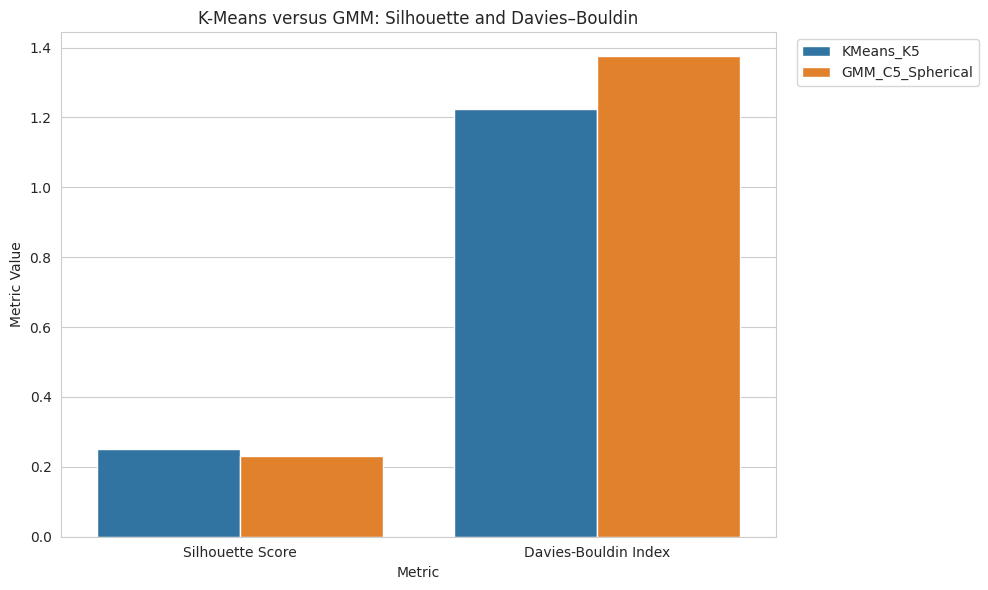

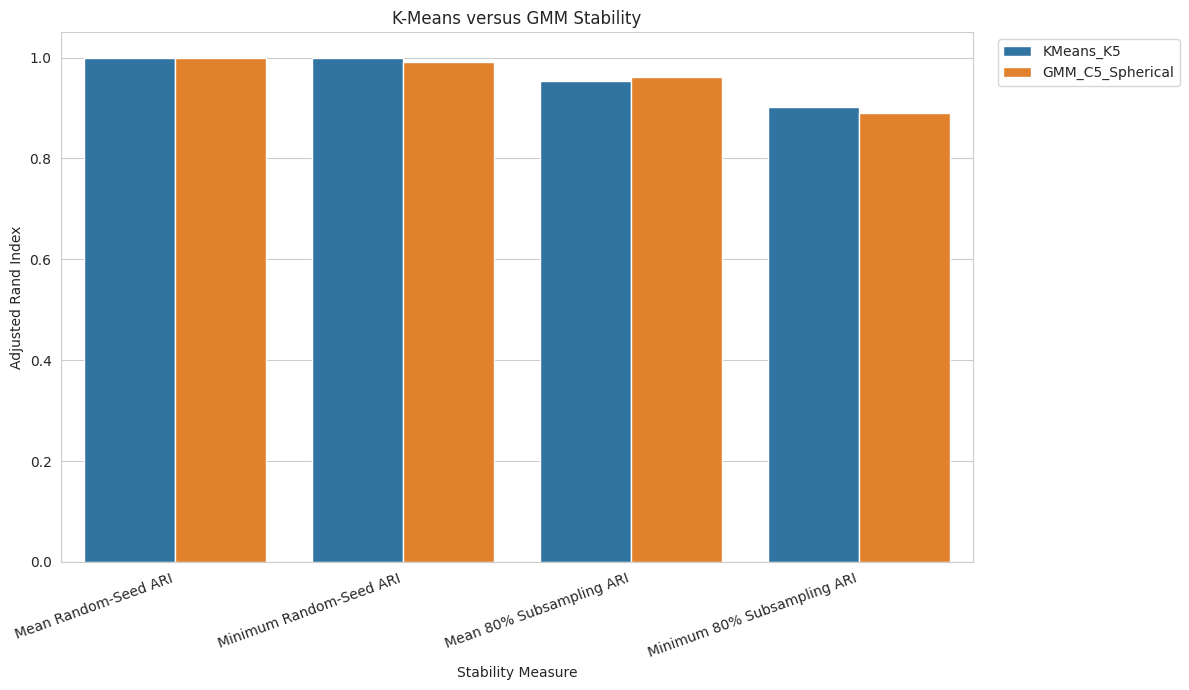

In [39]:
common_validation_plot = (
    technical_comparison[
        technical_comparison[
            "Metric"
        ].isin(
            [
                "Silhouette Score",
                "Davies-Bouldin Index"
            ]
        )
    ]
    .melt(
        id_vars=[
            "Metric",
            "Preferred_Direction"
        ],
        value_vars=[
            "KMeans_K5",
            "GMM_C5_Spherical"
        ],
        var_name="Model",
        value_name="Value"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_validation_plot,
    x="Metric",
    y="Value",
    hue="Model"
)

plt.title(
    "K-Means versus GMM: Silhouette and Davies–Bouldin"
)
plt.xlabel("Metric")
plt.ylabel("Metric Value")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_vs_gmm_silhouette_dbi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

stability_plot = (
    technical_comparison[
        technical_comparison[
            "Metric"
        ].isin(
            [
                "Mean Random-Seed ARI",
                "Minimum Random-Seed ARI",
                "Mean 80% Subsampling ARI",
                "Minimum 80% Subsampling ARI"
            ]
        )
    ]
    .melt(
        id_vars="Metric",
        value_vars=[
            "KMeans_K5",
            "GMM_C5_Spherical"
        ],
        var_name="Model",
        value_name="ARI"
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=stability_plot,
    x="Metric",
    y="ARI",
    hue="Model"
)

plt.title(
    "K-Means versus GMM Stability"
)
plt.xlabel("Stability Measure")
plt.ylabel("Adjusted Rand Index")
plt.ylim(0, 1.05)
plt.xticks(
    rotation=20,
    ha="right"
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_vs_gmm_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

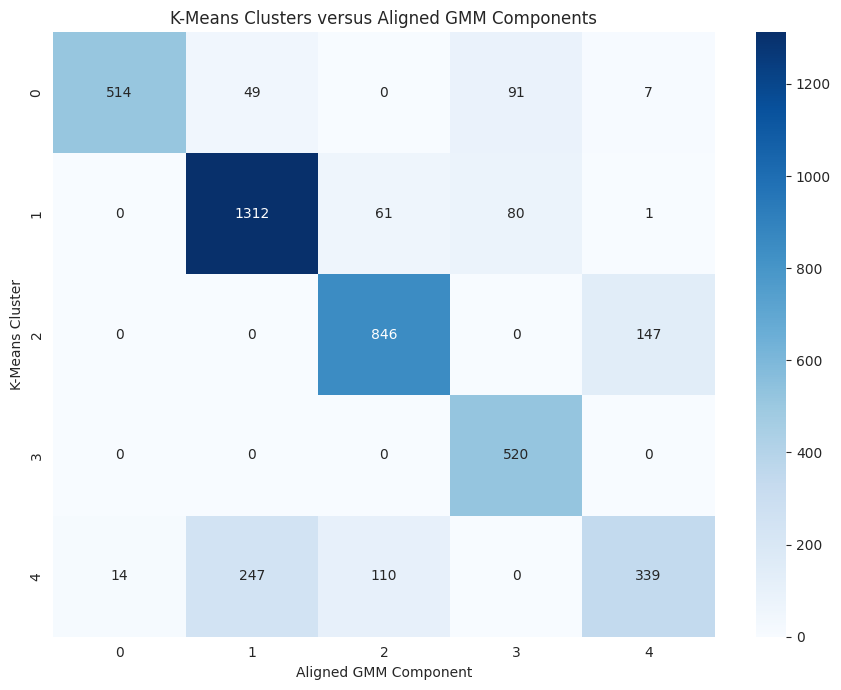

<Figure size 1000x600 with 0 Axes>

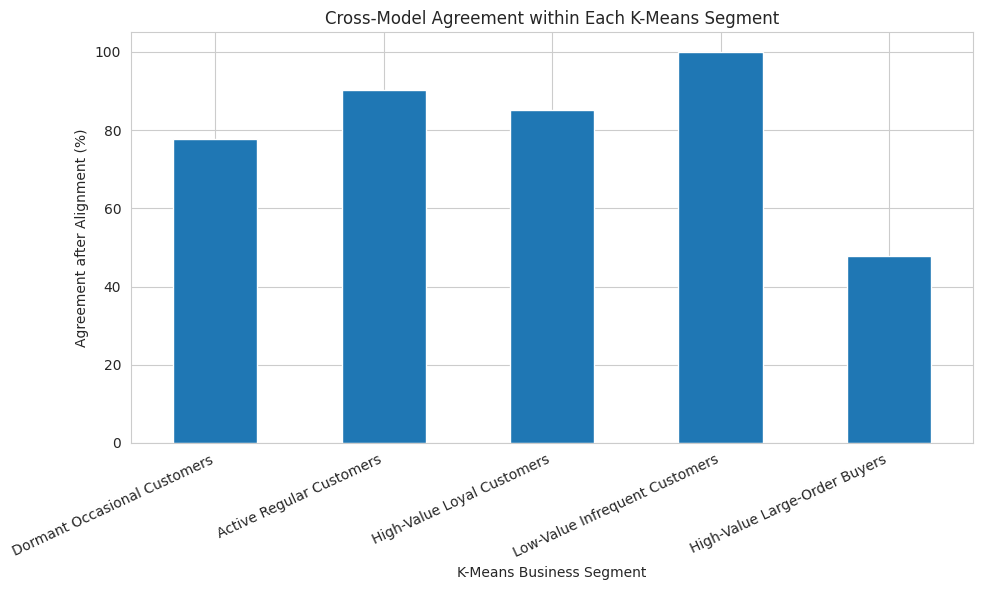

In [40]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    aligned_assignment_matrix.iloc[
        :-1,
        :-1
    ],
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "K-Means Clusters versus Aligned GMM Components"
)
plt.xlabel("Aligned GMM Component")
plt.ylabel("K-Means Cluster")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_vs_aligned_gmm_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

movement_summary.plot(
    kind="bar",
    x="KMeans_Segment",
    y="Agreement_Percentage",
    legend=False,
    figsize=(10, 6)
)

plt.title(
    "Cross-Model Agreement within Each K-Means Segment"
)
plt.xlabel("K-Means Business Segment")
plt.ylabel("Agreement after Alignment (%)")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "cross_model_agreement_by_kmeans_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

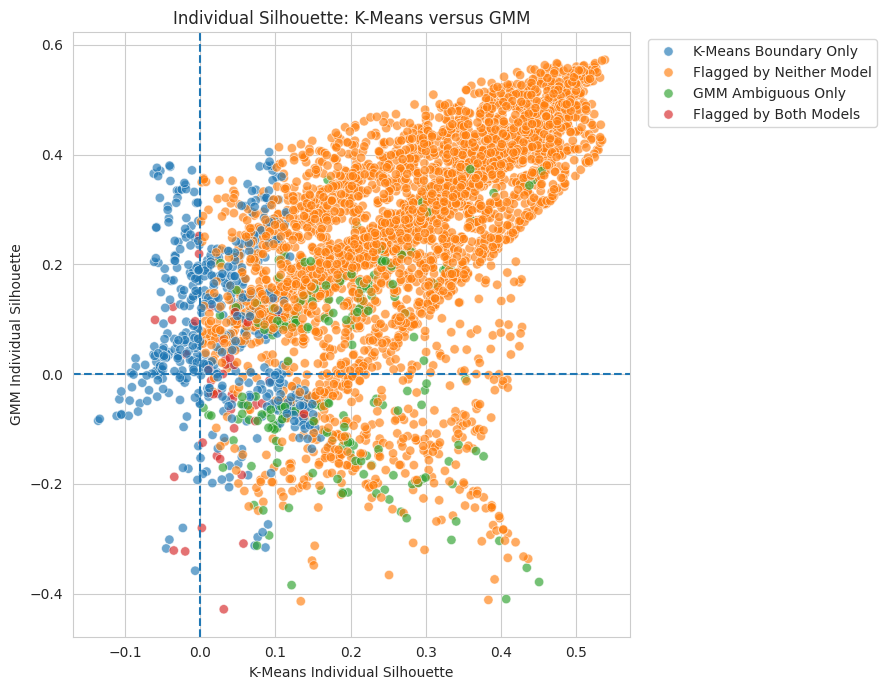

<Figure size 1000x600 with 0 Axes>

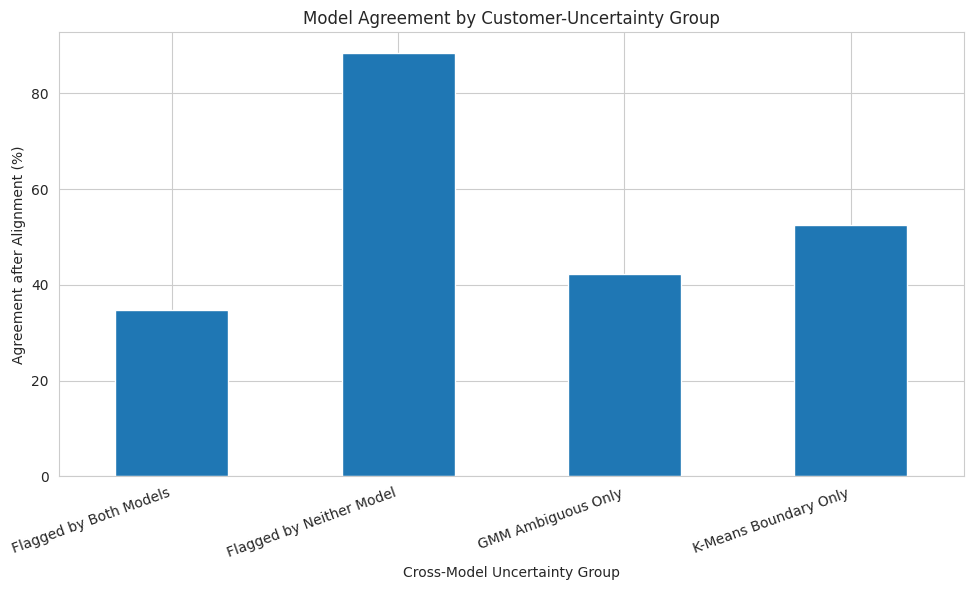

In [41]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=customer_model_comparison,
    x="Silhouette_Value_KMeans",
    y="Silhouette_Value_GMM",
    hue="Cross_Model_Uncertainty_Group",
    alpha=0.65,
    s=45
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Individual Silhouette: K-Means versus GMM"
)
plt.xlabel("K-Means Individual Silhouette")
plt.ylabel("GMM Individual Silhouette")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "individual_silhouette_cross_model_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

agreement_by_cross_uncertainty.plot(
    kind="bar",
    x="Cross_Model_Uncertainty_Group",
    y="Models_Agree_Percentage",
    legend=False,
    figsize=(10, 6)
)

plt.title(
    "Model Agreement by Customer-Uncertainty Group"
)
plt.xlabel("Cross-Model Uncertainty Group")
plt.ylabel("Agreement after Alignment (%)")
plt.xticks(
    rotation=20,
    ha="right"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "model_agreement_by_uncertainty_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## A12. Export the customer-level model-comparison datasets


In [42]:
customer_model_comparison.to_csv(
    DATASETS_DIR
    / "kmeans_vs_gmm_customer_comparison.csv",
    index=False
)

disagreement_customers = (
    customer_model_comparison[
        ~customer_model_comparison[
            "Models_Agree_After_Alignment"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Cross_Model_Uncertainty_Group",
            "CustomerID"
        ]
    )
    .reset_index(drop=True)
)

disagreement_customers.to_csv(
    DATASETS_DIR
    / "kmeans_vs_gmm_disagreement_customers.csv",
    index=False
)

both_uncertain_customers = (
    customer_model_comparison[
        customer_model_comparison[
            "Cross_Model_Uncertainty_Group"
        ] == "Flagged by Both Models"
    ]
    .copy()
    .reset_index(drop=True)
)

both_uncertain_customers.to_csv(
    DATASETS_DIR
    / "customers_flagged_uncertain_by_both_models.csv",
    index=False
)

print("Customer-level comparison datasets exported.")

Customer-level comparison datasets exported.


## A13. Run Phase A quality checks


In [43]:
assert len(
    customer_model_comparison
) == EXPECTED_CUSTOMERS

assert customer_model_comparison[
    "CustomerID"
].is_unique

assert (
    customer_model_comparison[
        "Cluster"
    ].nunique()
    == EXPECTED_GROUPS
)

assert (
    customer_model_comparison[
        "GMM_Component"
    ].nunique()
    == EXPECTED_GROUPS
)

assert set(
    gmm_to_kmeans_mapping.keys()
) == set(
    range(EXPECTED_GROUPS)
)

assert set(
    gmm_to_kmeans_mapping.values()
) == set(
    range(EXPECTED_GROUPS)
)

assert (
    confidence_overlap_summary[
        "Customer_Count"
    ].iloc[
        0:4
    ].sum()
    == EXPECTED_CUSTOMERS
)

assert (
    negative_silhouette_comparison[
        "Customer_Count"
    ].sum()
    == EXPECTED_CUSTOMERS
)

assert agreement_summary[
    "Value"
].between(
    0,
    1,
    inclusive="both"
).all()

assert alignment_summary[
    "Value"
].between(
    0,
    1,
    inclusive="both"
).all()

required_outputs = [
    TABLES_DIR
    / "kmeans_vs_gmm_common_technical_metrics.csv",
    TABLES_DIR
    / "kmeans_vs_gmm_assignment_agreement.csv",
    TABLES_DIR
    / "kmeans_vs_gmm_confidence_overlap_summary.csv",
    TABLES_DIR
    / "individual_silhouette_relationship_summary.csv",
    ALIGNMENT_DIR
    / "gmm_to_kmeans_overlap_alignment.csv",
    ALIGNMENT_DIR
    / "kmeans_vs_aligned_gmm_assignment_matrix.csv",
    DATASETS_DIR
    / "kmeans_vs_gmm_customer_comparison.csv",
    DATASETS_DIR
    / "kmeans_vs_gmm_disagreement_customers.csv"
]

missing_outputs = [
    str(path)
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing comparison outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "Customer population remains 4,338",
        "CustomerID values are unique",
        "K-Means contains five groups",
        "GMM contains five groups",
        "Alignment maps every GMM component once",
        "Alignment maps to every K-Means cluster once",
        "Confidence overlap categories sum to 4,338",
        "Negative-Silhouette categories sum to 4,338",
        "Unaligned agreement metrics are valid",
        "Aligned agreement metrics are valid",
        "Required comparison outputs created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    QUALITY_DIR
    / "kmeans_vs_gmm_comparison_quality_checks.csv",
    index=False
)

print(
    "All K-Means versus GMM comparison checks passed."
)

,Quality_Check,Passed
0,"Customer population remains 4,338",True
1,CustomerID values are unique,True
2,K-Means contains five groups,True
3,GMM contains five groups,True
4,Alignment maps every GMM component once,True
5,Alignment maps to every K-Means cluster once,True
6,"Confidence overlap categories sum to 4,338",True
7,"Negative-Silhouette categories sum to 4,338",True
8,Unaligned agreement metrics are valid,True
9,Aligned agreement metrics are valid,True


All K-Means versus GMM comparison checks passed.


## A14. Phase A technical conclusion

The comparison stage answers whether the two frozen algorithms reproduce similar customer structure and where they disagree.

The final decision is intentionally deferred until the aligned original-scale profiles and business actionability are evaluated in Phase B.


In [44]:
kmeans_boundary_percentage = float(
    kmeans_boundary_flag.mean()
    * 100
)

gmm_ambiguous_percentage = float(
    gmm_ambiguous_flag.mean()
    * 100
)

comparison_summary = {
    "models": [
        "K-Means K=5",
        "GMM C5 Spherical"
    ],
    "customers": EXPECTED_CUSTOMERS,
    "features": FEATURE_COLUMNS,
    "common_technical_metrics": {
        row["Metric"]: {
            "kmeans": float(
                row["KMeans_K5"]
            ),
            "gmm": float(
                row["GMM_C5_Spherical"]
            ),
            "metric_preference": (
                row["Metric_Preference"]
            )
        }
        for _, row in (
            technical_comparison.iterrows()
        )
    },
    "assignment_agreement": {
        "adjusted_rand_index": float(
            cross_model_ari
        ),
        "normalised_mutual_information": float(
            cross_model_nmi
        ),
        "exact_agreement_after_alignment": float(
            aligned_exact_agreement
        )
    },
    "confidence_evidence": {
        "kmeans_boundary_percentage": (
            kmeans_boundary_percentage
        ),
        "gmm_ambiguous_percentage": (
            gmm_ambiguous_percentage
        ),
        "customers_flagged_by_both": int(
            both_uncertain_flag.sum()
        ),
        "uncertainty_jaccard": float(
            uncertainty_jaccard
        ),
        "uncertainty_kappa": float(
            uncertainty_kappa
        )
    },
    "decision_status": (
        "No final model selected in Phase A."
    ),
    "next_step": (
        "Align and interpret original-scale model profiles, "
        "assign defensible GMM business names and evaluate "
        "business actionability."
    )
}

with open(
    RESULTS_DIR
    / "phase_a_kmeans_vs_gmm_comparison_summary.json",
    "w"
) as file:
    json.dump(
        comparison_summary,
        file,
        indent=4
    )

print(
    json.dumps(
        comparison_summary,
        indent=4
    )
)

{
    "models": [
        "K-Means K=5",
        "GMM C5 Spherical"
    ],
    "customers": 4338,
    "features": [
        "Recency",
        "Frequency",
        "Monetary",
        "AverageOrderValue",
        "BasketSize",
        "ProductDiversity",
        "TotalQuantity"
    ],
    "common_technical_metrics": {
        "Silhouette Score": {
            "kmeans": 0.251204,
            "gmm": 0.229893,
            "metric_preference": "K-Means K=5"
        },
        "Davies-Bouldin Index": {
            "kmeans": 1.223032,
            "gmm": 1.374938,
            "metric_preference": "K-Means K=5"
        },
        "Calinski-Harabasz Index": {
            "kmeans": 1755.968475,
            "gmm": 1587.495152,
            "metric_preference": "K-Means K=5"
        },
        "Mean Random-Seed ARI": {
            "kmeans": 0.999917,
            "gmm": 0.998484,
            "metric_preference": "K-Means K=5"
        },
        "Minimum Random-Seed ARI": {
            "kmeans": 0.99

# Phase B — Aligned Profile Interpretation and Final Model Decision

Customer overlap alone does not establish that two aligned groups have the same business meaning.

This phase therefore evaluates:

- original-scale means, medians and quartiles;
- customer and Monetary contribution;
- relative behavioural profile signatures;
- aligned profile similarity;
- segment distinctiveness;
- high-value customer redistribution;
- business objectives, recommended actions, KPIs and operational priorities.

The final operational-model decision is made only after this evidence is added to the technical comparison.


In [45]:
# Phase A outputs remain in memory; reuse them directly.

customer_data = customer_model_comparison.copy()
technical_metrics = technical_comparison.copy()
assignment_agreement = agreement_summary.copy()
aligned_matrix = aligned_assignment_matrix.copy()
confidence_overlap = confidence_overlap_summary.copy()
silhouette_relationship = silhouette_relationship_summary.copy()
phase_a_quality_checks = quality_checks.copy()

# Phase B-specific output folders already exist:
print("Profile folder:", PROFILES_DIR)
print("Strategy folder:", STRATEGY_DIR)
print("Decision folder:", DECISION_DIR)

required_customer_columns = [
    "CustomerID",
    *FEATURE_COLUMNS,
    "Cluster",
    "Segment_Name",
    "GMM_Component",
    "Aligned_GMM_Cluster",
    "Models_Agree_After_Alignment",
    "Combined_Boundary_Flag",
    "Combined_Ambiguous_Flag",
    "Assignment_Confidence_Category",
    "Membership_Confidence_Category"
]

missing_customer_columns = [
    column
    for column in required_customer_columns
    if column not in customer_data.columns
]

if missing_customer_columns:
    raise ValueError(
        "Missing customer-comparison columns: "
        f"{missing_customer_columns}"
    )

if len(customer_data) != EXPECTED_CUSTOMERS:
    raise ValueError(
        f"Expected {EXPECTED_CUSTOMERS:,} customers, "
        f"but found {len(customer_data):,}."
    )

if not customer_data["CustomerID"].is_unique:
    raise ValueError(
        "CustomerID values are not unique."
    )

if not phase_a_quality_checks["Passed"].all():
    raise ValueError(
        "At least one Phase A quality check failed."
    )

print("=" * 80)
print("PHASE B INPUTS VALIDATED")
print("=" * 80)
print("Customers:", len(customer_data))
print("K-Means groups:", customer_data["Cluster"].nunique())
print("GMM groups:", customer_data["GMM_Component"].nunique())


Profile folder: /content/06_Final_Model_Comparison_and_Business_Interpretation_Results/Profiles
Strategy folder: /content/06_Final_Model_Comparison_and_Business_Interpretation_Results/Strategy
Decision folder: /content/06_Final_Model_Comparison_and_Business_Interpretation_Results/Decision
PHASE B INPUTS VALIDATED
Customers: 4338
K-Means groups: 5
GMM groups: 5


## B1. Assign defensible business names to aligned GMM groups

The first four aligned GMM profiles closely correspond to established
K-Means behavioural groups.

The fifth GMM profile is not forced to retain the K-Means name
`High-Value Large-Order Buyers`. Its original-scale profile combines:

- the highest Monetary value;
- the highest Average Order Value;
- the largest Basket Size;
- high purchase Frequency;
- high Total Quantity.

It is therefore named:

> **Elite High-Value Customers**

This name reflects both high cumulative value and high order intensity without
making an unverified wholesale or business-to-business claim.

In [46]:
GMM_NAME_BY_ALIGNED_CLUSTER = {
    0: "Dormant Occasional Customers",
    1: "Active Regular Customers",
    2: "High-Value Loyal Customers",
    3: "Low-Value Infrequent Customers",
    4: "Elite High-Value Customers"
}

GMM_DESCRIPTION_BY_ALIGNED_CLUSTER = {
    0: (
        "Long-inactive customers with few purchases "
        "and limited total value."
    ),
    1: (
        "Recently active customers with regular but "
        "moderate purchasing behaviour."
    ),
    2: (
        "Recent, frequent and high-value customers "
        "with broad product engagement."
    ),
    3: (
        "Low-frequency customers with low spending, "
        "small baskets and limited product diversity."
    ),
    4: (
        "Very high-value customers combining large "
        "orders, high quantities and strong purchase frequency."
    )
}

customer_data[
    "GMM_Segment_Name"
] = (
    customer_data[
        "Aligned_GMM_Cluster"
    ]
    .map(
        GMM_NAME_BY_ALIGNED_CLUSTER
    )
)

customer_data[
    "GMM_Segment_Description"
] = (
    customer_data[
        "Aligned_GMM_Cluster"
    ]
    .map(
        GMM_DESCRIPTION_BY_ALIGNED_CLUSTER
    )
)

if customer_data[
    "GMM_Segment_Name"
].isnull().any():
    raise ValueError(
        "At least one aligned GMM group was not named."
    )

gmm_name_mapping = (
    customer_data[
        [
            "GMM_Component",
            "Aligned_GMM_Cluster",
            "GMM_Segment_Name",
            "GMM_Segment_Description"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "Aligned_GMM_Cluster"
    )
    .reset_index(drop=True)
)

display(gmm_name_mapping)

gmm_name_mapping.to_csv(
    TABLES_DIR
    / "final_gmm_component_business_name_mapping.csv",
    index=False
)

,GMM_Component,Aligned_GMM_Cluster,GMM_Segment_Name,GMM_Segment_Description
0,3,0,Dormant Occasional Customers,Long-inactive customers with few purchases and...
1,0,1,Active Regular Customers,Recently active customers with regular but mod...
2,2,2,High-Value Loyal Customers,"Recent, frequent and high-value customers with..."
3,4,3,Low-Value Infrequent Customers,"Low-frequency customers with low spending, sma..."
4,1,4,Elite High-Value Customers,Very high-value customers combining large orde...


## B2. Define original-scale profile functions


In [47]:
def create_model_profile(
    data,
    model_name,
    group_column,
    name_column
):

    grouped = data.groupby(
        [
            group_column,
            name_column
        ]
    )

    summary = grouped.agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Total_Monetary=(
            "Monetary",
            "sum"
        )
    ).reset_index()

    summary[
        "Customer_Percentage"
    ] = (
        summary[
            "Customer_Count"
        ]
        / len(data)
        * 100
    )

    summary[
        "Monetary_Contribution_Percentage"
    ] = (
        summary[
            "Total_Monetary"
        ]
        / data[
            "Monetary"
        ].sum()
        * 100
    )

    mean_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .mean()
        .reset_index()
    )

    median_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .median()
        .reset_index()
    )

    q1_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .quantile(0.25)
        .reset_index()
    )

    q3_profile = (
        grouped[
            FEATURE_COLUMNS
        ]
        .quantile(0.75)
        .reset_index()
    )

    summary.insert(
        0,
        "Model",
        model_name
    )

    mean_profile.insert(
        0,
        "Model",
        model_name
    )

    median_profile.insert(
        0,
        "Model",
        model_name
    )

    q1_profile.insert(
        0,
        "Model",
        model_name
    )

    q3_profile.insert(
        0,
        "Model",
        model_name
    )

    return {
        "summary": summary,
        "mean": mean_profile,
        "median": median_profile,
        "q1": q1_profile,
        "q3": q3_profile
    }


kmeans_profiles = create_model_profile(
    data=customer_data,
    model_name="K-Means K=5",
    group_column="Cluster",
    name_column="Segment_Name"
)

gmm_profiles = create_model_profile(
    data=customer_data,
    model_name="GMM C5 Spherical",
    group_column="Aligned_GMM_Cluster",
    name_column="GMM_Segment_Name"
)

display(kmeans_profiles["summary"])
display(gmm_profiles["summary"])

,Model,Cluster,Segment_Name,Customer_Count,Total_Monetary,Customer_Percentage,Monetary_Contribution_Percentage
0,K-Means K=5,0,Dormant Occasional Customers,661,"239,320.1800",15.2374,2.6929
1,K-Means K=5,1,Active Regular Customers,1454,"904,586.0130",33.5178,10.1785
2,K-Means K=5,2,High-Value Loyal Customers,993,"6,192,568.2900",22.8907,69.6796
3,K-Means K=5,3,Low-Value Infrequent Customers,520,"85,841.8500",11.9871,0.9659
4,K-Means K=5,4,High-Value Large-Order Buyers,710,"1,464,892.5610",16.3670,16.4832


,Model,Aligned_GMM_Cluster,GMM_Segment_Name,Customer_Count,Total_Monetary,Customer_Percentage,Monetary_Contribution_Percentage
0,GMM C5 Spherical,0,Dormant Occasional Customers,528,"193,797.8100",12.1715,2.1806
1,GMM C5 Spherical,1,Active Regular Customers,1608,"1,007,713.4830",37.0678,11.3389
2,GMM C5 Spherical,2,High-Value Loyal Customers,1017,"2,946,930.5500",23.4440,33.1592
3,GMM C5 Spherical,3,Low-Value Infrequent Customers,691,"142,011.6100",15.9290,1.5979
4,GMM C5 Spherical,4,Elite High-Value Customers,494,"4,596,755.4410",11.3877,51.7233


## B3. Export complete mean, median and quartile profiles


In [48]:
for profile_name, profile_data in (
    kmeans_profiles.items()
):
    profile_data.to_csv(
        PROFILES_DIR
        / f"kmeans_{profile_name}_profile.csv",
        index=False
    )

for profile_name, profile_data in (
    gmm_profiles.items()
):
    profile_data.to_csv(
        PROFILES_DIR
        / f"gmm_{profile_name}_profile.csv",
        index=False
    )

combined_segment_summary = pd.concat(
    [
        kmeans_profiles[
            "summary"
        ].rename(
            columns={
                "Cluster": "Group_Number",
                "Segment_Name": "Business_Segment"
            }
        ),
        gmm_profiles[
            "summary"
        ].rename(
            columns={
                "Aligned_GMM_Cluster": "Group_Number",
                "GMM_Segment_Name": "Business_Segment"
            }
        )
    ],
    ignore_index=True
)

display(combined_segment_summary)

combined_segment_summary.to_csv(
    TABLES_DIR
    / "combined_model_segment_summary.csv",
    index=False
)

,Model,Group_Number,Business_Segment,Customer_Count,Total_Monetary,Customer_Percentage,Monetary_Contribution_Percentage
0,K-Means K=5,0,Dormant Occasional Customers,661,"239,320.1800",15.2374,2.6929
1,K-Means K=5,1,Active Regular Customers,1454,"904,586.0130",33.5178,10.1785
2,K-Means K=5,2,High-Value Loyal Customers,993,"6,192,568.2900",22.8907,69.6796
3,K-Means K=5,3,Low-Value Infrequent Customers,520,"85,841.8500",11.9871,0.9659
4,K-Means K=5,4,High-Value Large-Order Buyers,710,"1,464,892.5610",16.3670,16.4832
5,GMM C5 Spherical,0,Dormant Occasional Customers,528,"193,797.8100",12.1715,2.1806
6,GMM C5 Spherical,1,Active Regular Customers,1608,"1,007,713.4830",37.0678,11.3389
7,GMM C5 Spherical,2,High-Value Loyal Customers,1017,"2,946,930.5500",23.4440,33.1592
8,GMM C5 Spherical,3,Low-Value Infrequent Customers,691,"142,011.6100",15.9290,1.5979
9,GMM C5 Spherical,4,Elite High-Value Customers,494,"4,596,755.4410",11.3877,51.7233


## B4. Create relative mean and median profile signatures

Feature scales differ substantially. Direct Euclidean comparison of raw means
would allow Monetary and Total Quantity to dominate.

For descriptive profile comparison, each group profile is expressed as:

\[
\log_2
\left(
rac{	ext{group statistic}+1}
{	ext{overall statistic}+1}

ight)
\]

Interpretation:

- zero: approximately equal to the overall customer population;
- positive: above the overall value;
- negative: below the overall value.

The same transformation is applied to both models.

In [49]:
overall_mean = customer_data[
    FEATURE_COLUMNS
].mean()

overall_median = customer_data[
    FEATURE_COLUMNS
].median()


def create_relative_signature(
    profile_data,
    group_column,
    name_column,
    overall_statistic
):

    signature = profile_data[
        [
            group_column,
            name_column,
            *FEATURE_COLUMNS
        ]
    ].copy()

    for feature in FEATURE_COLUMNS:
        signature[
            feature
        ] = np.log2(
            (
                signature[
                    feature
                ] + 1
            )
            /
            (
                overall_statistic[
                    feature
                ] + 1
            )
        )

    return signature


kmeans_mean_signature = (
    create_relative_signature(
        kmeans_profiles["mean"],
        "Cluster",
        "Segment_Name",
        overall_mean
    )
)

gmm_mean_signature = (
    create_relative_signature(
        gmm_profiles["mean"],
        "Aligned_GMM_Cluster",
        "GMM_Segment_Name",
        overall_mean
    )
)

kmeans_median_signature = (
    create_relative_signature(
        kmeans_profiles["median"],
        "Cluster",
        "Segment_Name",
        overall_median
    )
)

gmm_median_signature = (
    create_relative_signature(
        gmm_profiles["median"],
        "Aligned_GMM_Cluster",
        "GMM_Segment_Name",
        overall_median
    )
)

kmeans_mean_signature.to_csv(
    PROFILES_DIR
    / "kmeans_relative_mean_signature.csv",
    index=False
)

gmm_mean_signature.to_csv(
    PROFILES_DIR
    / "gmm_relative_mean_signature.csv",
    index=False
)

kmeans_median_signature.to_csv(
    PROFILES_DIR
    / "kmeans_relative_median_signature.csv",
    index=False
)

gmm_median_signature.to_csv(
    PROFILES_DIR
    / "gmm_relative_median_signature.csv",
    index=False
)

## B5. Measure aligned customer overlap and profile similarity

For every aligned pair, the notebook reports:

- customer intersection;
- percentage of the K-Means group retained by GMM;
- percentage of the GMM group originating from the aligned K-Means group;
- Jaccard overlap;
- Spearman correlation between relative mean signatures;
- Spearman correlation between relative median signatures;
- Euclidean distance between the relative signatures.

These are descriptive alignment measures, not supervised accuracy.

In [50]:
aligned_profile_rows = []

for aligned_group in range(
    EXPECTED_GROUPS
):

    kmeans_group_data = customer_data[
        customer_data[
            "Cluster"
        ] == aligned_group
    ]

    gmm_group_data = customer_data[
        customer_data[
            "Aligned_GMM_Cluster"
        ] == aligned_group
    ]

    intersection_count = int(
        (
            (
                customer_data[
                    "Cluster"
                ] == aligned_group
            )
            &
            (
                customer_data[
                    "Aligned_GMM_Cluster"
                ] == aligned_group
            )
        ).sum()
    )

    kmeans_count = int(
        len(kmeans_group_data)
    )

    gmm_count = int(
        len(gmm_group_data)
    )

    union_count = (
        kmeans_count
        + gmm_count
        - intersection_count
    )

    kmeans_mean_vector = (
        kmeans_mean_signature[
            kmeans_mean_signature[
                "Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    gmm_mean_vector = (
        gmm_mean_signature[
            gmm_mean_signature[
                "Aligned_GMM_Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    kmeans_median_vector = (
        kmeans_median_signature[
            kmeans_median_signature[
                "Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    gmm_median_vector = (
        gmm_median_signature[
            gmm_median_signature[
                "Aligned_GMM_Cluster"
            ] == aligned_group
        ][FEATURE_COLUMNS]
        .iloc[0]
        .to_numpy()
    )

    mean_spearman, _ = spearmanr(
        kmeans_mean_vector,
        gmm_mean_vector
    )

    median_spearman, _ = spearmanr(
        kmeans_median_vector,
        gmm_median_vector
    )

    aligned_profile_rows.append({
        "Aligned_Group": aligned_group,
        "KMeans_Segment": (
            kmeans_group_data[
                "Segment_Name"
            ].iloc[0]
        ),
        "GMM_Segment": (
            gmm_group_data[
                "GMM_Segment_Name"
            ].iloc[0]
        ),
        "KMeans_Customer_Count": (
            kmeans_count
        ),
        "GMM_Customer_Count": (
            gmm_count
        ),
        "Customer_Intersection": (
            intersection_count
        ),
        "KMeans_Retention_Percentage": (
            intersection_count
            / kmeans_count
            * 100
        ),
        "GMM_Aligned_Origin_Percentage": (
            intersection_count
            / gmm_count
            * 100
        ),
        "Jaccard_Overlap": (
            intersection_count
            / union_count
        ),
        "Relative_Mean_Profile_Spearman": (
            mean_spearman
        ),
        "Relative_Median_Profile_Spearman": (
            median_spearman
        ),
        "Relative_Mean_Profile_Distance": (
            euclidean(
                kmeans_mean_vector,
                gmm_mean_vector
            )
        ),
        "Relative_Median_Profile_Distance": (
            euclidean(
                kmeans_median_vector,
                gmm_median_vector
            )
        )
    })

aligned_profile_evidence = (
    pd.DataFrame(
        aligned_profile_rows
    )
    .round(4)
)

display(aligned_profile_evidence)

aligned_profile_evidence.to_csv(
    TABLES_DIR
    / "aligned_group_profile_and_overlap_evidence.csv",
    index=False
)

,Aligned_Group,KMeans_Segment,GMM_Segment,KMeans_Customer_Count,GMM_Customer_Count,Customer_Intersection,KMeans_Retention_Percentage,GMM_Aligned_Origin_Percentage,Jaccard_Overlap,Relative_Mean_Profile_Spearman,Relative_Median_Profile_Spearman,Relative_Mean_Profile_Distance,Relative_Median_Profile_Distance
0,0,Dormant Occasional Customers,Dormant Occasional Customers,661,528,514,77.7610,97.3485,0.7615,1.0000,1.0000,0.2171,0.2745
1,1,Active Regular Customers,Active Regular Customers,1454,1608,1312,90.2338,81.5920,0.7497,0.6071,0.8929,0.4480,0.4231
2,2,High-Value Loyal Customers,High-Value Loyal Customers,993,1017,846,85.1964,83.1858,0.7268,0.6429,1.0000,1.6808,0.5785
3,3,Low-Value Infrequent Customers,Low-Value Infrequent Customers,520,691,520,100.0000,75.2533,0.7525,1.0000,1.0000,0.7043,0.4774
4,4,High-Value Large-Order Buyers,Elite High-Value Customers,710,494,339,47.7465,68.6235,0.3919,0.5357,0.6786,3.6049,1.6993


## B6. Identify the defining features of every segment

The top defining features are selected from the absolute relative median
signature.

For Recency, a negative value means the group purchased more recently than the
overall population, while a positive value means greater inactivity.

In [51]:
def defining_feature_table(
    signature_data,
    model_name,
    group_column,
    name_column
):

    rows = []

    for _, profile_row in (
        signature_data.iterrows()
    ):

        feature_values = {
            feature: float(
                profile_row[
                    feature
                ]
            )
            for feature in FEATURE_COLUMNS
        }

        ranked_features = sorted(
            feature_values.items(),
            key=lambda item: abs(
                item[1]
            ),
            reverse=True
        )

        for rank, (
            feature,
            relative_value
        ) in enumerate(
            ranked_features[
                :3
            ],
            start=1
        ):

            if feature == "Recency":
                direction = (
                    "More inactive than overall"
                    if relative_value > 0
                    else "More recent than overall"
                )
            else:
                direction = (
                    "Above overall"
                    if relative_value > 0
                    else "Below overall"
                )

            rows.append({
                "Model": model_name,
                "Group_Number": int(
                    profile_row[
                        group_column
                    ]
                ),
                "Business_Segment": (
                    profile_row[
                        name_column
                    ]
                ),
                "Feature_Rank": rank,
                "Defining_Feature": feature,
                "Relative_Log2_Value": (
                    relative_value
                ),
                "Direction": direction
            })

    return pd.DataFrame(
        rows
    )


kmeans_defining_features = (
    defining_feature_table(
        kmeans_median_signature,
        "K-Means K=5",
        "Cluster",
        "Segment_Name"
    )
)

gmm_defining_features = (
    defining_feature_table(
        gmm_median_signature,
        "GMM C5 Spherical",
        "Aligned_GMM_Cluster",
        "GMM_Segment_Name"
    )
)

combined_defining_features = pd.concat(
    [
        kmeans_defining_features,
        gmm_defining_features
    ],
    ignore_index=True
).round(4)

display(combined_defining_features)

combined_defining_features.to_csv(
    TABLES_DIR
    / "segment_top_defining_features.csv",
    index=False
)

,Model,Group_Number,Business_Segment,Feature_Rank,Defining_Feature,Relative_Log2_Value,Direction
0,K-Means K=5,0,Dormant Occasional Customers,1,Recency,2.3385,More inactive than overall
1,K-Means K=5,0,Dormant Occasional Customers,2,TotalQuantity,-1.2714,Below overall
2,K-Means K=5,0,Dormant Occasional Customers,3,Monetary,-1.0991,Below overall
3,K-Means K=5,1,Active Regular Customers,1,Recency,-0.5305,More recent than overall
4,K-Means K=5,1,Active Regular Customers,2,TotalQuantity,-0.3615,Below overall
5,K-Means K=5,1,Active Regular Customers,3,AverageOrderValue,-0.3549,Below overall
6,K-Means K=5,2,High-Value Loyal Customers,1,TotalQuantity,2.2054,Above overall
7,K-Means K=5,2,High-Value Loyal Customers,2,Monetary,2.1095,Above overall
8,K-Means K=5,2,High-Value Loyal Customers,3,Recency,-1.7004,More recent than overall
9,K-Means K=5,3,Low-Value Infrequent Customers,1,TotalQuantity,-2.7716,Below overall


## B7. Compare within-model profile distinctiveness

Pairwise distances are calculated among the five relative median signatures
within each model.

A larger distance means the business profiles differ more strongly across the
seven features.

This is a descriptive profile comparison, not a replacement for Silhouette,
DBI or CH.

In [52]:
def profile_distinctiveness(
    signature_data,
    model_name
):

    matrix = signature_data[
        FEATURE_COLUMNS
    ].to_numpy()

    distances = pdist(
        matrix,
        metric="euclidean"
    )

    return {
        "Model": model_name,
        "Mean_Pairwise_Profile_Distance": float(
            distances.mean()
        ),
        "Median_Pairwise_Profile_Distance": float(
            np.median(
                distances
            )
        ),
        "Minimum_Pairwise_Profile_Distance": float(
            distances.min()
        ),
        "Maximum_Pairwise_Profile_Distance": float(
            distances.max()
        )
    }


profile_distinctiveness_summary = pd.DataFrame([
    profile_distinctiveness(
        kmeans_median_signature,
        "K-Means K=5"
    ),
    profile_distinctiveness(
        gmm_median_signature,
        "GMM C5 Spherical"
    )
]).round(4)

display(profile_distinctiveness_summary)

profile_distinctiveness_summary.to_csv(
    TABLES_DIR
    / "model_profile_distinctiveness_summary.csv",
    index=False
)

,Model,Mean_Pairwise_Profile_Distance,Median_Pairwise_Profile_Distance,Minimum_Pairwise_Profile_Distance,Maximum_Pairwise_Profile_Distance
0,K-Means K=5,4.9693,4.4034,2.9027,9.0357
1,GMM C5 Spherical,4.9812,4.2148,2.8480,8.1360


## B8. Map model groups to business objectives, actions and KPIs

Strategies are linked to observed customer behaviour.

They are analytical recommendations, not experimentally validated campaign
outcomes.

In [53]:
strategy_rows = [
    {
        "Model": "K-Means K=5",
        "Group_Number": 0,
        "Business_Segment": "Dormant Occasional Customers",
        "Primary_Objective": "Reactivation",
        "Recommended_Action": (
            "Low-cost win-back communication with "
            "time-limited personalised incentives."
        ),
        "Primary_KPI": "Reactivation rate",
        "Operational_Priority": "Medium"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 1,
        "Business_Segment": "Active Regular Customers",
        "Primary_Objective": "Develop customer value",
        "Recommended_Action": (
            "Cross-sell relevant products and encourage "
            "the next purchase through loyalty milestones."
        ),
        "Primary_KPI": "Purchase frequency",
        "Operational_Priority": "High"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 2,
        "Business_Segment": "High-Value Loyal Customers",
        "Primary_Objective": "Retention",
        "Recommended_Action": (
            "VIP recognition, priority service and "
            "early-access retention benefits."
        ),
        "Primary_KPI": "Revenue retention",
        "Operational_Priority": "Very High"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 3,
        "Business_Segment": "Low-Value Infrequent Customers",
        "Primary_Objective": "Efficient nurture",
        "Recommended_Action": (
            "Automated low-cost offers and product "
            "recommendations with controlled campaign spend."
        ),
        "Primary_KPI": "Conversion rate",
        "Operational_Priority": "Low"
    },
    {
        "Model": "K-Means K=5",
        "Group_Number": 4,
        "Business_Segment": "High-Value Large-Order Buyers",
        "Primary_Objective": "Protect order value",
        "Recommended_Action": (
            "Order-value incentives, replenishment reminders "
            "and priority support for large purchases."
        ),
        "Primary_KPI": "Average order value",
        "Operational_Priority": "Very High"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 0,
        "Business_Segment": "Dormant Occasional Customers",
        "Primary_Objective": "Reactivation",
        "Recommended_Action": (
            "Low-cost win-back communication with "
            "time-limited personalised incentives."
        ),
        "Primary_KPI": "Reactivation rate",
        "Operational_Priority": "Medium"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 1,
        "Business_Segment": "Active Regular Customers",
        "Primary_Objective": "Develop customer value",
        "Recommended_Action": (
            "Cross-sell relevant products and encourage "
            "the next purchase through loyalty milestones."
        ),
        "Primary_KPI": "Purchase frequency",
        "Operational_Priority": "High"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 2,
        "Business_Segment": "High-Value Loyal Customers",
        "Primary_Objective": "Retention and frequency",
        "Recommended_Action": (
            "Loyalty recognition, tailored cross-sell and "
            "early intervention when activity declines."
        ),
        "Primary_KPI": "Retention and purchase frequency",
        "Operational_Priority": "Very High"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 3,
        "Business_Segment": "Low-Value Infrequent Customers",
        "Primary_Objective": "Efficient nurture",
        "Recommended_Action": (
            "Automated low-cost offers and product "
            "recommendations with controlled campaign spend."
        ),
        "Primary_KPI": "Conversion rate",
        "Operational_Priority": "Low"
    },
    {
        "Model": "GMM C5 Spherical",
        "Group_Number": 4,
        "Business_Segment": "Elite High-Value Customers",
        "Primary_Objective": "Priority retention",
        "Recommended_Action": (
            "Dedicated high-value treatment, priority support, "
            "exclusive benefits and proactive churn prevention."
        ),
        "Primary_KPI": "High-value revenue retention",
        "Operational_Priority": "Critical"
    }
]

business_strategy_mapping = pd.DataFrame(
    strategy_rows
)

display(business_strategy_mapping)

business_strategy_mapping.to_csv(
    STRATEGY_DIR
    / "model_segment_business_strategy_mapping.csv",
    index=False
)

,Model,Group_Number,Business_Segment,Primary_Objective,Recommended_Action,Primary_KPI,Operational_Priority
0,K-Means K=5,0,Dormant Occasional Customers,Reactivation,Low-cost win-back communication with time-limi...,Reactivation rate,Medium
1,K-Means K=5,1,Active Regular Customers,Develop customer value,Cross-sell relevant products and encourage the...,Purchase frequency,High
2,K-Means K=5,2,High-Value Loyal Customers,Retention,"VIP recognition, priority service and early-ac...",Revenue retention,Very High
3,K-Means K=5,3,Low-Value Infrequent Customers,Efficient nurture,Automated low-cost offers and product recommen...,Conversion rate,Low
4,K-Means K=5,4,High-Value Large-Order Buyers,Protect order value,"Order-value incentives, replenishment reminder...",Average order value,Very High
5,GMM C5 Spherical,0,Dormant Occasional Customers,Reactivation,Low-cost win-back communication with time-limi...,Reactivation rate,Medium
6,GMM C5 Spherical,1,Active Regular Customers,Develop customer value,Cross-sell relevant products and encourage the...,Purchase frequency,High
7,GMM C5 Spherical,2,High-Value Loyal Customers,Retention and frequency,"Loyalty recognition, tailored cross-sell and e...",Retention and purchase frequency,Very High
8,GMM C5 Spherical,3,Low-Value Infrequent Customers,Efficient nurture,Automated low-cost offers and product recommen...,Conversion rate,Low
9,GMM C5 Spherical,4,Elite High-Value Customers,Priority retention,"Dedicated high-value treatment, priority suppo...",High-value revenue retention,Critical


## B9. Examine high-value customer redistribution

The largest model difference occurs around the K-Means
`High-Value Large-Order Buyers` group.

GMM creates a smaller `Elite High-Value Customers` component and redistributes
the remaining customers according to its probabilistic component structure.

This section quantifies that difference.

In [54]:
high_value_customer_movements = (
    customer_data[
        customer_data[
            "Segment_Name"
        ].isin(
            [
                "High-Value Loyal Customers",
                "High-Value Large-Order Buyers"
            ]
        )
    ]
    .groupby(
        [
            "Segment_Name",
            "GMM_Segment_Name"
        ]
    )
    .agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Total_Monetary=(
            "Monetary",
            "sum"
        ),
        Median_Monetary=(
            "Monetary",
            "median"
        ),
        Median_Frequency=(
            "Frequency",
            "median"
        ),
        Median_AverageOrderValue=(
            "AverageOrderValue",
            "median"
        ),
        Median_BasketSize=(
            "BasketSize",
            "median"
        )
    )
    .reset_index()
)

high_value_customer_movements[
    "Percentage_Within_KMeans_Segment"
] = (
    high_value_customer_movements[
        "Customer_Count"
    ]
    / high_value_customer_movements
    .groupby(
        "Segment_Name"
    )[
        "Customer_Count"
    ]
    .transform("sum")
    * 100
)

high_value_customer_movements = (
    high_value_customer_movements
    .sort_values(
        [
            "Segment_Name",
            "Customer_Count"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(4)
)

display(high_value_customer_movements)

high_value_customer_movements.to_csv(
    TABLES_DIR
    / "high_value_customer_redistribution.csv",
    index=False
)

,Segment_Name,GMM_Segment_Name,Customer_Count,Total_Monetary,Median_Monetary,Median_Frequency,Median_AverageOrderValue,Median_BasketSize,Percentage_Within_KMeans_Segment
2,High-Value Large-Order Buyers,Elite High-Value Customers,339,"1,077,535.9810","1,563.0000",2.0000,912.8200,576.5000,47.7465
0,High-Value Large-Order Buyers,Active Regular Customers,247,"195,934.6400",752.6000,2.0000,465.8800,300.0000,34.7887
3,High-Value Large-Order Buyers,High-Value Loyal Customers,110,"181,582.3400","1,586.7050",3.0000,478.4800,312.2500,15.4930
1,High-Value Large-Order Buyers,Dormant Occasional Customers,14,"9,839.6000",612.3150,1.0000,571.3000,287.2500,1.9718
5,High-Value Loyal Customers,High-Value Loyal Customers,846,"2,686,452.3500","2,609.7300",7.0000,355.9050,214.9250,85.1964
4,High-Value Loyal Customers,Elite High-Value Customers,147,"3,506,115.9400","11,528.4800",15.0000,790.0100,444.1600,14.8036


## B10. Visualise aligned business profiles


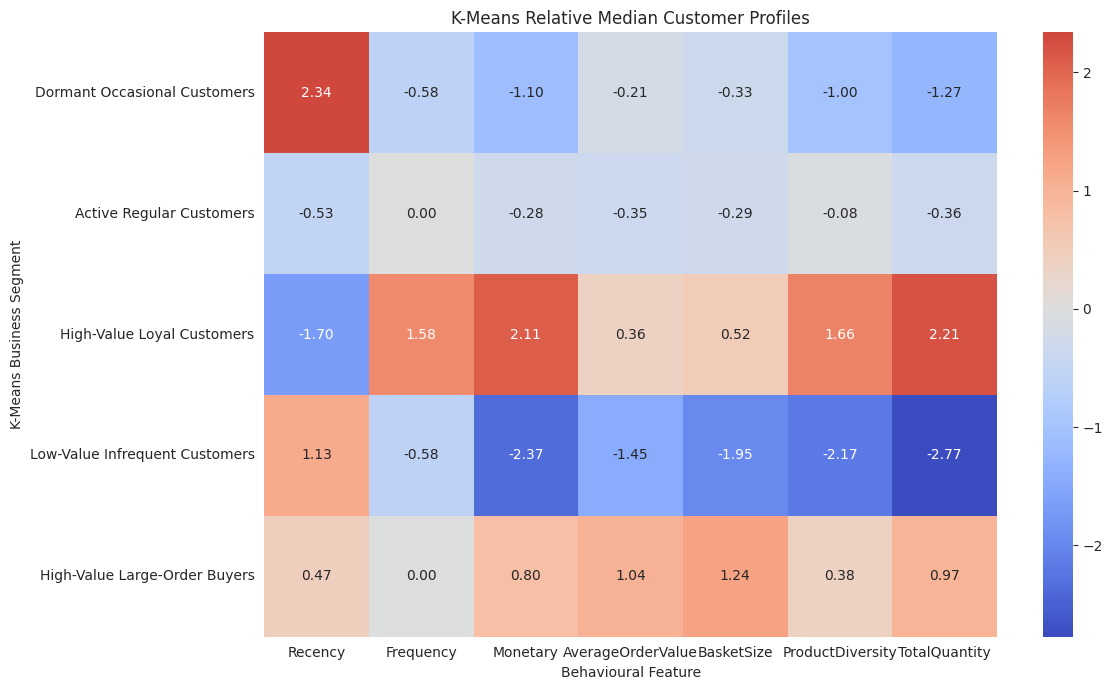

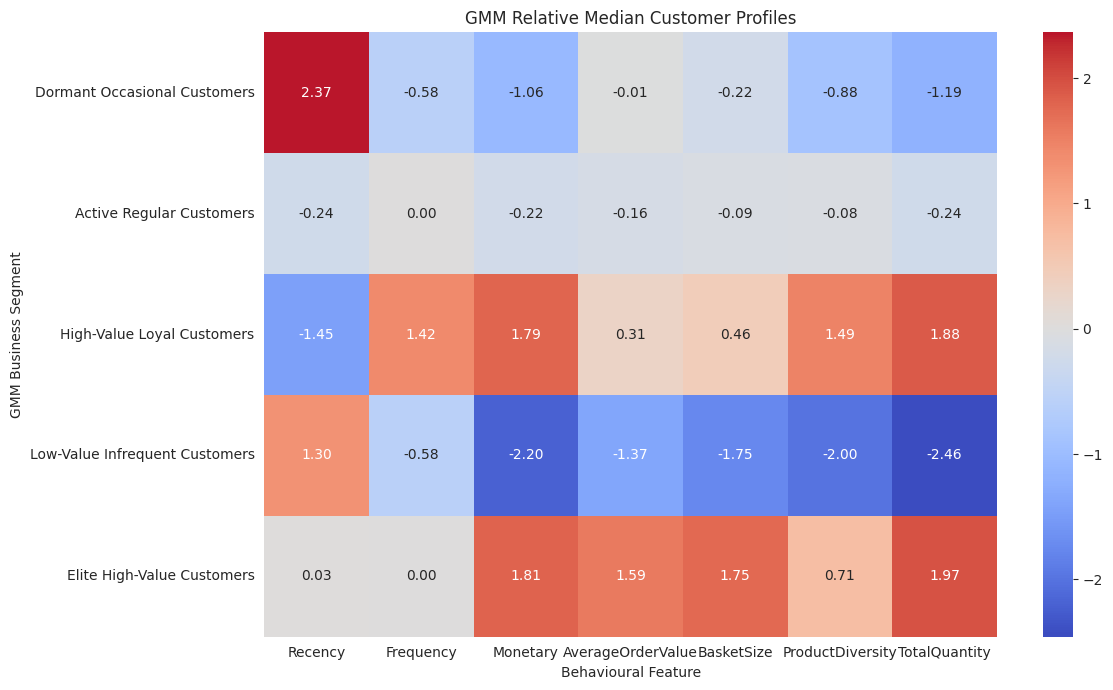

In [55]:
kmeans_heatmap = (
    kmeans_median_signature
    .set_index(
        "Segment_Name"
    )[
        FEATURE_COLUMNS
    ]
)

gmm_heatmap = (
    gmm_median_signature
    .set_index(
        "GMM_Segment_Name"
    )[
        FEATURE_COLUMNS
    ]
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    kmeans_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "K-Means Relative Median Customer Profiles"
)
plt.xlabel("Behavioural Feature")
plt.ylabel("K-Means Business Segment")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_relative_median_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(12, 7))

sns.heatmap(
    gmm_heatmap,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "GMM Relative Median Customer Profiles"
)
plt.xlabel("Behavioural Feature")
plt.ylabel("GMM Business Segment")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gmm_relative_median_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

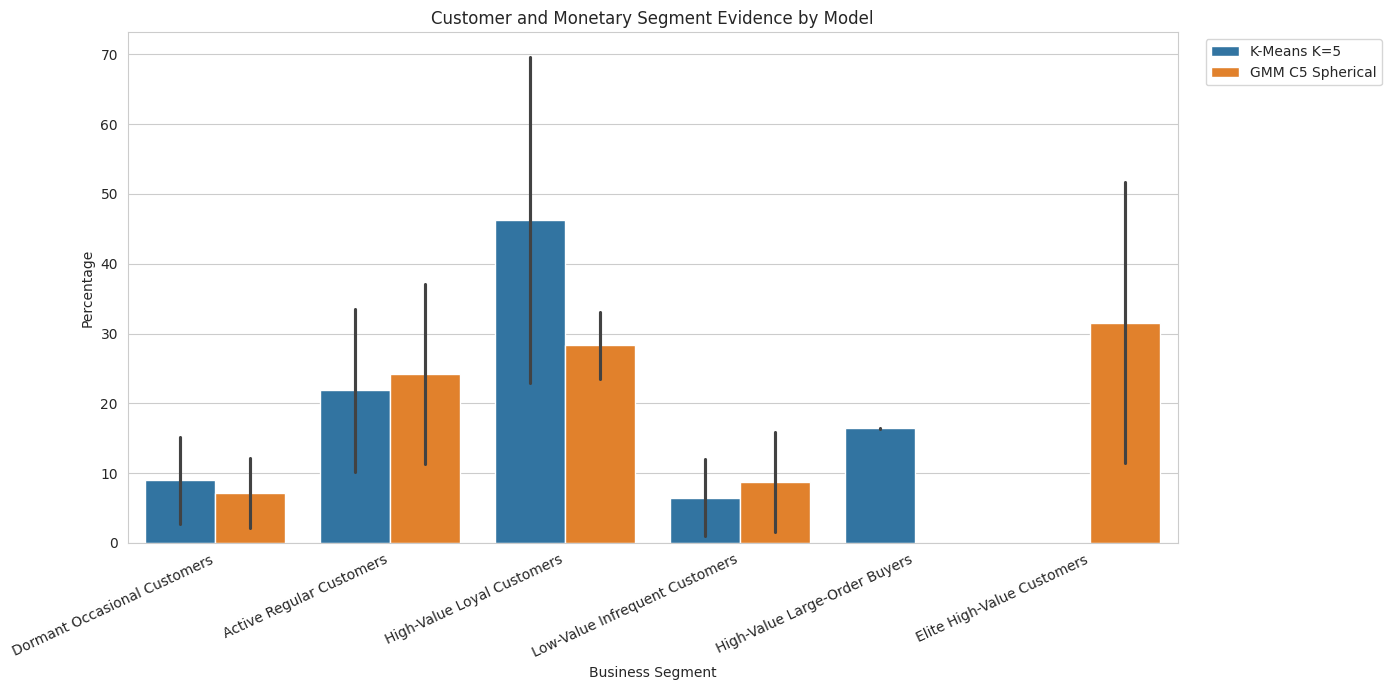

In [56]:
segment_share_plot = (
    combined_segment_summary[
        [
            "Model",
            "Business_Segment",
            "Customer_Percentage",
            "Monetary_Contribution_Percentage"
        ]
    ]
    .melt(
        id_vars=[
            "Model",
            "Business_Segment"
        ],
        var_name="Share_Type",
        value_name="Percentage"
    )
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=segment_share_plot,
    x="Business_Segment",
    y="Percentage",
    hue="Model"
)

plt.title(
    "Customer and Monetary Segment Evidence by Model"
)
plt.xlabel("Business Segment")
plt.ylabel("Percentage")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "combined_segment_share_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1100x600 with 0 Axes>

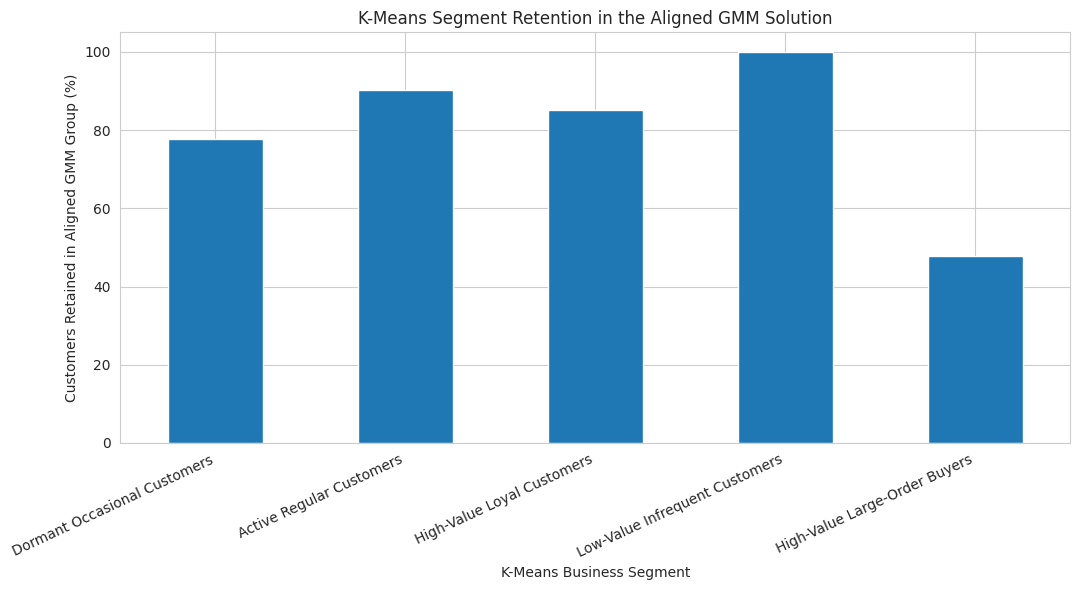

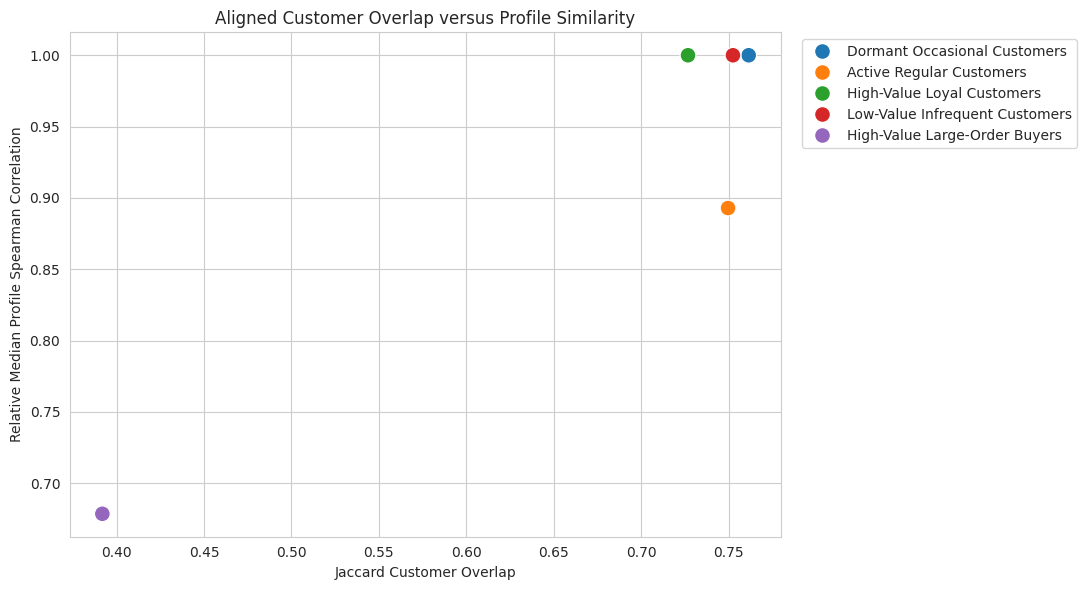

In [57]:
plt.figure(figsize=(11, 6))

aligned_profile_evidence.plot(
    kind="bar",
    x="KMeans_Segment",
    y="KMeans_Retention_Percentage",
    legend=False,
    figsize=(11, 6)
)

plt.title(
    "K-Means Segment Retention in the Aligned GMM Solution"
)
plt.xlabel("K-Means Business Segment")
plt.ylabel("Customers Retained in Aligned GMM Group (%)")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "aligned_segment_customer_retention.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=aligned_profile_evidence,
    x="Jaccard_Overlap",
    y="Relative_Median_Profile_Spearman",
    hue="KMeans_Segment",
    s=130
)

plt.title(
    "Aligned Customer Overlap versus Profile Similarity"
)
plt.xlabel("Jaccard Customer Overlap")
plt.ylabel("Relative Median Profile Spearman Correlation")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "aligned_overlap_vs_profile_similarity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## B11. Build the final multi-criteria evidence table

The final recommendation distinguishes:

- technical separation;
- stability;
- operational feasibility;
- assignment agreement;
- interpretability;
- uncertainty support;
- model simplicity.

The table records evidence and trade-offs rather than counting equal-weight
metric wins.

In [58]:
technical_lookup = (
    technical_metrics
    .set_index(
        "Metric"
    )
)

assignment_ari = float(
    assignment_agreement.loc[
        assignment_agreement[
            "Agreement_Measure"
        ] == "Adjusted Rand Index",
        "Value"
    ].iloc[0]
)

assignment_nmi = float(
    assignment_agreement.loc[
        assignment_agreement[
            "Agreement_Measure"
        ] == "Normalised Mutual Information",
        "Value"
    ].iloc[0]
)

aligned_exact_agreement = float(
    customer_data[
        "Models_Agree_After_Alignment"
    ].mean()
)

kmeans_negative_silhouette_percentage = float(
    (
        customer_data[
            "Silhouette_Value_KMeans"
        ] < 0
    ).mean()
    * 100
)

gmm_negative_silhouette_percentage = float(
    (
        customer_data[
            "Silhouette_Value_GMM"
        ] < 0
    ).mean()
    * 100
)

kmeans_boundary_percentage = float(
    customer_data[
        "Combined_Boundary_Flag"
    ].mean()
    * 100
)

gmm_ambiguous_percentage = float(
    customer_data[
        "Combined_Ambiguous_Flag"
    ].mean()
    * 100
)

final_evidence_rows = [
    {
        "Criterion": "Common internal validation",
        "KMeans_Evidence": (
            "Higher Silhouette and CH; lower DBI."
        ),
        "GMM_Evidence": (
            "Acceptable but weaker on all three "
            "common internal metrics."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Random-seed stability",
        "KMeans_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean Random-Seed ARI', 'KMeans_K5']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum Random-Seed ARI', 'KMeans_K5']:.4f}."
        ),
        "GMM_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean Random-Seed ARI', 'GMM_C5_Spherical']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum Random-Seed ARI', 'GMM_C5_Spherical']:.4f}."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Subsampling stability",
        "KMeans_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean 80% Subsampling ARI', 'KMeans_K5']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum 80% Subsampling ARI', 'KMeans_K5']:.4f}."
        ),
        "GMM_Evidence": (
            "Mean ARI "
            f"{technical_lookup.loc['Mean 80% Subsampling ARI', 'GMM_C5_Spherical']:.4f}; "
            "minimum "
            f"{technical_lookup.loc['Minimum 80% Subsampling ARI', 'GMM_C5_Spherical']:.4f}."
        ),
        "Evidence_Preference": (
            "Both strong; GMM higher mean, K-Means stronger minimum"
        ),
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Group-size feasibility",
        "KMeans_Evidence": (
            "Smallest group "
            f"{technical_lookup.loc['Smallest Group Percentage', 'KMeans_K5']:.2f}%."
        ),
        "GMM_Evidence": (
            "Smallest group "
            f"{technical_lookup.loc['Smallest Group Percentage', 'GMM_C5_Spherical']:.2f}%."
        ),
        "Evidence_Preference": "Both feasible",
        "Decision_Weight": "Required gate"
    },
    {
        "Criterion": "Cross-model structural agreement",
        "KMeans_Evidence": (
            f"ARI={assignment_ari:.4f}, "
            f"NMI={assignment_nmi:.4f}, "
            f"aligned agreement={aligned_exact_agreement * 100:.2f}%."
        ),
        "GMM_Evidence": (
            "Substantial common structure with "
            "meaningful differences in high-value customers."
        ),
        "Evidence_Preference": "Complementary evidence",
        "Decision_Weight": "Contextual"
    },
    {
        "Criterion": "Geometric boundary evidence",
        "KMeans_Evidence": (
            f"Negative Silhouette: "
            f"{kmeans_negative_silhouette_percentage:.2f}%."
        ),
        "GMM_Evidence": (
            f"Negative Silhouette: "
            f"{gmm_negative_silhouette_percentage:.2f}%."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "Medium"
    },
    {
        "Criterion": "Customer-level uncertainty capability",
        "KMeans_Evidence": (
            f"Centroid and Silhouette review group: "
            f"{kmeans_boundary_percentage:.2f}%."
        ),
        "GMM_Evidence": (
            f"Probability-based ambiguous group: "
            f"{gmm_ambiguous_percentage:.2f}%; "
            "also provides full posterior probabilities."
        ),
        "Evidence_Preference": "GMM C5 Spherical",
        "Decision_Weight": "Supporting"
    },
    {
        "Criterion": "Business interpretability",
        "KMeans_Evidence": (
            "Five established and directly explainable "
            "customer profiles."
        ),
        "GMM_Evidence": (
            "Four close analogues plus an informative "
            "elite high-value component."
        ),
        "Evidence_Preference": (
            "K-Means primary; GMM adds refinement"
        ),
        "Decision_Weight": "High"
    },
    {
        "Criterion": "Operational simplicity",
        "KMeans_Evidence": (
            "Nearest-centroid assignment is simple to "
            "explain, reproduce and deploy."
        ),
        "GMM_Evidence": (
            "Probability model provides richer evidence "
            "but requires more explanation."
        ),
        "Evidence_Preference": "K-Means K=5",
        "Decision_Weight": "Medium"
    }
]

final_evidence_table = pd.DataFrame(
    final_evidence_rows
)

display(final_evidence_table)

final_evidence_table.to_csv(
    DECISION_DIR
    / "final_multi_criteria_model_evidence.csv",
    index=False
)

,Criterion,KMeans_Evidence,GMM_Evidence,Evidence_Preference,Decision_Weight
0,Common internal validation,Higher Silhouette and CH; lower DBI.,Acceptable but weaker on all three common inte...,K-Means K=5,High
1,Random-seed stability,Mean ARI 0.9999; minimum 0.9996.,Mean ARI 0.9985; minimum 0.9918.,K-Means K=5,High
2,Subsampling stability,Mean ARI 0.9541; minimum 0.9011.,Mean ARI 0.9610; minimum 0.8898.,"Both strong; GMM higher mean, K-Means stronger...",High
3,Group-size feasibility,Smallest group 11.99%.,Smallest group 11.39%.,Both feasible,Required gate
4,Cross-model structural agreement,"ARI=0.6289, NMI=0.6512, aligned agreement=81.40%.",Substantial common structure with meaningful d...,Complementary evidence,Contextual
5,Geometric boundary evidence,Negative Silhouette: 4.73%.,Negative Silhouette: 14.48%.,K-Means K=5,Medium
6,Customer-level uncertainty capability,Centroid and Silhouette review group: 12.47%.,Probability-based ambiguous group: 5.97%; also...,GMM C5 Spherical,Supporting
7,Business interpretability,Five established and directly explainable cust...,Four close analogues plus an informative elite...,K-Means primary; GMM adds refinement,High
8,Operational simplicity,Nearest-centroid assignment is simple to expla...,Probability model provides richer evidence but...,K-Means K=5,Medium


## B12. Record the final operational-model decision

### Primary model

K-Means K=5 is retained as the primary operational segmentation because it:

- performs better on all three common internal validation metrics;
- has near-perfect random-seed stability;
- has a stronger worst-case subsampling result;
- creates five practical, established and directly actionable customer groups;
- is simpler to explain and reproduce.

### Supporting model

GMM C5 spherical is retained as a comparative and uncertainty-analysis layer
because it:

- demonstrates that the main customer structure is largely reproduced;
- provides posterior membership probabilities;
- identifies alternative components and customer overlap;
- reveals a concentrated `Elite High-Value Customers` group;
- provides additional evidence around customers near behavioural boundaries.

The GMM result adds analytical value without replacing the more transparent
K-Means operational segmentation.

In [59]:
final_model_decision = {
    "primary_operational_model": {
        "model": "K-Means K=5",
        "status": "Selected",
        "reasons": [
            (
                "Stronger Silhouette, Davies-Bouldin and "
                "Calinski-Harabasz results."
            ),
            (
                "Near-perfect random-seed stability and "
                "strong worst-case subsampling stability."
            ),
            (
                "Five practical and directly actionable "
                "business profiles."
            ),
            (
                "Simpler assignment logic and stronger "
                "operational transparency."
            )
        ]
    },
    "supporting_comparative_model": {
        "model": "GMM C5 Spherical",
        "status": (
            "Retained as probabilistic comparison "
            "and customer-confidence layer"
        ),
        "contributions": [
            (
                "Posterior probabilities for all five components."
            ),
            (
                "Alternative-component and entropy evidence."
            ),
            (
                "Substantial reproduction of the main "
                "five-group customer structure."
            ),
            (
                "Identification of a concentrated elite "
                "high-value customer group."
            )
        ]
    },
    "cross_model_evidence": {
        "adjusted_rand_index": (
            assignment_ari
        ),
        "normalised_mutual_information": (
            assignment_nmi
        ),
        "exact_agreement_after_alignment": (
            aligned_exact_agreement
        )
    },
    "important_limitation": (
        "The final recommendation is based on internal "
        "validation, stability and business interpretation. "
        "No ground-truth customer segment labels or campaign "
        "outcome experiment is available."
    ),
    "dashboard_recommendation": (
        "Use K-Means segment as the primary business segment. "
        "Display GMM component, maximum probability, alternative "
        "component and confidence status as a supporting layer."
    )
}

with open(
    DECISION_DIR
    / "final_operational_model_decision.json",
    "w"
) as file:
    json.dump(
        final_model_decision,
        file,
        indent=4
    )

print(
    json.dumps(
        final_model_decision,
        indent=4
    )
)

{
    "primary_operational_model": {
        "model": "K-Means K=5",
        "status": "Selected",
        "reasons": [
            "Stronger Silhouette, Davies-Bouldin and Calinski-Harabasz results.",
            "Near-perfect random-seed stability and strong worst-case subsampling stability.",
            "Five practical and directly actionable business profiles.",
            "Simpler assignment logic and stronger operational transparency."
        ]
    },
    "supporting_comparative_model": {
        "model": "GMM C5 Spherical",
        "status": "Retained as probabilistic comparison and customer-confidence layer",
        "contributions": [
            "Posterior probabilities for all five components.",
            "Alternative-component and entropy evidence.",
            "Substantial reproduction of the main five-group customer structure.",
            "Identification of a concentrated elite high-value customer group."
        ]
    },
    "cross_model_evidence": {
        "adj

## B13. Create final dashboard-ready datasets

The dashboard table contains:

- original customer behavioural features;
- primary K-Means business segment;
- K-Means confidence evidence;
- supporting GMM business segment;
- GMM probability evidence;
- aligned model agreement;
- cross-model uncertainty status;
- primary strategy and KPI.

In [60]:
primary_strategy_columns = (
    business_strategy_mapping[
        business_strategy_mapping[
            "Model"
        ] == "K-Means K=5"
    ][
        [
            "Group_Number",
            "Primary_Objective",
            "Recommended_Action",
            "Primary_KPI",
            "Operational_Priority"
        ]
    ]
    .rename(
        columns={
            "Group_Number": "Cluster"
        }
    )
)

dashboard_customer_data = (
    customer_data
    .merge(
        primary_strategy_columns,
        on="Cluster",
        how="left",
        validate="many_to_one"
    )
)

dashboard_customer_data[
    "Primary_Operational_Model"
] = "K-Means K=5"

dashboard_customer_data[
    "Supporting_Analytical_Model"
] = "GMM C5 Spherical"

dashboard_customer_data.to_csv(
    DATASETS_DIR
    / "final_customer_segmentation_dashboard_data.csv",
    index=False
)

combined_segment_summary.to_csv(
    DATASETS_DIR
    / "final_dashboard_segment_summary.csv",
    index=False
)

business_strategy_mapping.to_csv(
    DATASETS_DIR
    / "final_dashboard_strategy_mapping.csv",
    index=False
)

technical_metrics.to_csv(
    DATASETS_DIR
    / "final_dashboard_model_metrics.csv",
    index=False
)

print(
    "Final dashboard datasets exported."
)

Final dashboard datasets exported.


## B14. Run final profile and decision quality checks


In [61]:
assert len(
    dashboard_customer_data
) == EXPECTED_CUSTOMERS

assert dashboard_customer_data[
    "CustomerID"
].is_unique

assert dashboard_customer_data[
    "Segment_Name"
].notna().all()

assert dashboard_customer_data[
    "GMM_Segment_Name"
].notna().all()

assert set(
    dashboard_customer_data[
        "GMM_Segment_Name"
    ].unique()
) == set(
    GMM_NAME_BY_ALIGNED_CLUSTER.values()
)

assert np.isclose(
    kmeans_profiles[
        "summary"
    ][
        "Customer_Percentage"
    ].sum(),
    100
)

assert np.isclose(
    gmm_profiles[
        "summary"
    ][
        "Customer_Percentage"
    ].sum(),
    100
)

assert np.isclose(
    kmeans_profiles[
        "summary"
    ][
        "Monetary_Contribution_Percentage"
    ].sum(),
    100
)

assert np.isclose(
    gmm_profiles[
        "summary"
    ][
        "Monetary_Contribution_Percentage"
    ].sum(),
    100
)

assert len(
    aligned_profile_evidence
) == EXPECTED_GROUPS

assert len(
    business_strategy_mapping
) == EXPECTED_GROUPS * 2

required_outputs = [
    TABLES_DIR
    / "final_gmm_component_business_name_mapping.csv",
    TABLES_DIR
    / "combined_model_segment_summary.csv",
    TABLES_DIR
    / "aligned_group_profile_and_overlap_evidence.csv",
    TABLES_DIR
    / "segment_top_defining_features.csv",
    TABLES_DIR
    / "model_profile_distinctiveness_summary.csv",
    STRATEGY_DIR
    / "model_segment_business_strategy_mapping.csv",
    DECISION_DIR
    / "final_multi_criteria_model_evidence.csv",
    DECISION_DIR
    / "final_operational_model_decision.json",
    DATASETS_DIR
    / "final_customer_segmentation_dashboard_data.csv",
    DATASETS_DIR
    / "final_dashboard_segment_summary.csv",
    DATASETS_DIR
    / "final_dashboard_strategy_mapping.csv",
    DATASETS_DIR
    / "final_dashboard_model_metrics.csv"
]

missing_outputs = [
    str(path)
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing required Notebook 06 outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "Dashboard customer count remains 4,338",
        "CustomerID values remain unique",
        "All K-Means segment names complete",
        "All GMM segment names complete",
        "Five expected GMM names present",
        "K-Means customer percentages total 100",
        "GMM customer percentages total 100",
        "K-Means monetary shares total 100",
        "GMM monetary shares total 100",
        "Five aligned profile comparisons created",
        "Ten model-strategy rows created",
        "Required Notebook 06 outputs created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    QUALITY_DIR
    / "profile_alignment_and_final_decision_quality_checks.csv",
    index=False
)

print(
    "All Notebook 06 profile and decision quality checks passed."
)

,Quality_Check,Passed
0,"Dashboard customer count remains 4,338",True
1,CustomerID values remain unique,True
2,All K-Means segment names complete,True
3,All GMM segment names complete,True
4,Five expected GMM names present,True
5,K-Means customer percentages total 100,True
6,GMM customer percentages total 100,True
7,K-Means monetary shares total 100,True
8,GMM monetary shares total 100,True
9,Five aligned profile comparisons created,True


All Notebook 06 profile and decision quality checks passed.


## B15. Create the supervisor-ready final comparison summary


In [62]:
technical_metric_lookup = (
    technical_metrics
    .set_index(
        "Metric"
    )
)

largest_difference_row = (
    aligned_profile_evidence
    .sort_values(
        "KMeans_Retention_Percentage"
    )
    .iloc[0]
)

supervisor_summary = f'''
FINAL K-MEANS AND GMM PROFILE INTERPRETATION

Analytical population
---------------------
Customers: {EXPECTED_CUSTOMERS:,}
Features: {len(FEATURE_COLUMNS)}
Groups per model: {EXPECTED_GROUPS}

Technical comparison
--------------------
K-Means Silhouette:
{technical_metric_lookup.loc["Silhouette Score", "KMeans_K5"]:.4f}

GMM Silhouette:
{technical_metric_lookup.loc["Silhouette Score", "GMM_C5_Spherical"]:.4f}

K-Means Davies-Bouldin:
{technical_metric_lookup.loc["Davies-Bouldin Index", "KMeans_K5"]:.4f}

GMM Davies-Bouldin:
{technical_metric_lookup.loc["Davies-Bouldin Index", "GMM_C5_Spherical"]:.4f}

K-Means Calinski-Harabasz:
{technical_metric_lookup.loc["Calinski-Harabasz Index", "KMeans_K5"]:.2f}

GMM Calinski-Harabasz:
{technical_metric_lookup.loc["Calinski-Harabasz Index", "GMM_C5_Spherical"]:.2f}

Cross-model agreement
---------------------
Adjusted Rand Index:
{assignment_ari:.4f}

Normalised Mutual Information:
{assignment_nmi:.4f}

Exact agreement after alignment:
{aligned_exact_agreement * 100:.2f}%

Profile interpretation
----------------------
Four GMM groups retained business interpretations closely related
to the corresponding K-Means groups.

The fifth GMM group was named Elite High-Value Customers because
it combined very high Monetary value, Average Order Value,
Basket Size, Total Quantity and strong purchase Frequency.

Largest aligned difference
--------------------------
K-Means segment:
{largest_difference_row["KMeans_Segment"]}

Aligned GMM segment:
{largest_difference_row["GMM_Segment"]}

K-Means customers retained in the aligned GMM group:
{largest_difference_row["KMeans_Retention_Percentage"]:.2f}%

Final operational decision
--------------------------
Primary segmentation:
K-Means K=5

Supporting comparative and confidence model:
GMM C5 spherical

Rationale
---------
K-Means achieved stronger common internal validation, near-perfect
random-seed stability, a stronger worst-case subsampling result and
five directly actionable customer profiles.

GMM retained substantial common structure and added posterior
membership probabilities, alternative-component evidence and an
elite high-value refinement.

The dashboard should therefore use the K-Means segment as the
primary business group and display GMM membership evidence as a
supporting analytical layer.
'''.strip()

with open(
    RESULTS_DIR
    / "supervisor_final_model_decision_summary.txt",
    "w"
) as file:
    file.write(
        supervisor_summary
    )

print(supervisor_summary)

FINAL K-MEANS AND GMM PROFILE INTERPRETATION

Analytical population
---------------------
Customers: 4,338
Features: 7
Groups per model: 5

Technical comparison
--------------------
K-Means Silhouette:
0.2512

GMM Silhouette:
0.2299

K-Means Davies-Bouldin:
1.2230

GMM Davies-Bouldin:
1.3749

K-Means Calinski-Harabasz:
1755.97

GMM Calinski-Harabasz:
1587.50

Cross-model agreement
---------------------
Adjusted Rand Index:
0.6289

Normalised Mutual Information:
0.6512

Exact agreement after alignment:
81.40%

Profile interpretation
----------------------
Four GMM groups retained business interpretations closely related
to the corresponding K-Means groups.

The fifth GMM group was named Elite High-Value Customers because
it combined very high Monetary value, Average Order Value,
Basket Size, Total Quantity and strong purchase Frequency.

Largest aligned difference
--------------------------
K-Means segment:
High-Value Large-Order Buyers

Aligned GMM segment:
Elite High-Value Customers



In [63]:
step8_manifest = {
    "purpose": (
        "Align and interpret frozen K-Means K=5 and "
        "GMM C5 spherical customer profiles."
    ),
    "models_retrained": False,
    "customers": EXPECTED_CUSTOMERS,
    "features": FEATURE_COLUMNS,
    "alignment": {
        "source": (
            "Phase A Hungarian maximum-overlap mapping"
        ),
        "limitation": (
            "Customer overlap does not alone establish "
            "identical business meaning."
        )
    },
    "gmm_business_names": (
        GMM_NAME_BY_ALIGNED_CLUSTER
    ),
    "profile_comparison": {
        "statistics": [
            "mean",
            "median",
            "first quartile",
            "third quartile",
            "customer share",
            "monetary contribution"
        ],
        "relative_signature": (
            "Log2 ratio of group statistic plus one "
            "to overall statistic plus one."
        )
    },
    "final_decision": {
        "primary_operational_model": (
            "K-Means K=5"
        ),
        "supporting_model": (
            "GMM C5 Spherical"
        )
    },
    "dashboard_design": (
        "K-Means primary segment with GMM membership, "
        "probability and uncertainty as supporting fields."
    ),
    "important_limitations": [
        (
            "No ground-truth customer labels are available."
        ),
        (
            "Business strategies are analytical recommendations "
            "rather than experimentally validated outcomes."
        ),
        (
            "GMM posterior probabilities depend on the fitted "
            "mixture-model assumptions."
        )
    ]
}

with open(
    RESULTS_DIR
    / "notebook06_profile_interpretation_manifest.json",
    "w"
) as file:
    json.dump(
        step8_manifest,
        file,
        indent=4
    )

print(
    "Notebook 06 methodology manifest saved."
)

Notebook 06 methodology manifest saved.


# Final analytical conclusion

The two frozen algorithms reproduce a substantial common customer structure, but they are not identical.

## Primary operational model — K-Means K=5

K-Means remains the operational segmentation because it provides:

- stronger Silhouette, Davies–Bouldin and Calinski–Harabasz evidence;
- near-perfect random-seed stability;
- a stronger worst-case subsampling result;
- five practical and directly explainable business profiles;
- simpler hard assignments for CRM and campaign operations.

## Supporting analytical model — GMM C5 Spherical

GMM is retained because it adds:

- posterior probabilities for all five components;
- alternative-component evidence;
- probability margins and entropy;
- customer-level ambiguity analysis;
- an independent robustness comparison;
- a refined elite high-value customer grouping.

The dashboard therefore uses the K-Means segment as the **primary business segment** and GMM as the **supporting confidence and comparison layer**.


## 3. Package all final Notebook 06 results into one ZIP archive

In [64]:
notebook06_manifest = {
    "purpose": (
        "Compare frozen K-Means K=5 and GMM C5 Spherical, "
        "align customer groups, interpret original-scale profiles, "
        "map business strategies and make the final operational-model decision."
    ),
    "models_retrained": False,
    "customers": EXPECTED_CUSTOMERS,
    "features": FEATURE_COLUMNS,
    "primary_operational_model": "K-Means K=5",
    "supporting_analytical_model": "GMM C5 Spherical",
    "cross_model_evidence": {
        "adjusted_rand_index": float(assignment_ari),
        "normalised_mutual_information": float(assignment_nmi),
        "aligned_customer_agreement": float(aligned_exact_agreement)
    },
    "dashboard_output": (
        "Datasets/final_customer_segmentation_dashboard_data.csv"
    )
}

with open(
    RESULTS_DIR / "notebook06_final_manifest.json",
    "w"
) as file:
    json.dump(
        notebook06_manifest,
        file,
        indent=4
    )

zip_path = shutil.make_archive(
    base_name=str(
        BASE_DIR
        / "06_Final_Model_Comparison_and_Business_Interpretation_All_Results"
    ),
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("NOTEBOOK 06 — FINAL MODEL COMPARISON COMPLETED")
print("=" * 80)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nFinal model decision:")
print("Primary operational model: K-Means K=5")
print("Supporting analytical model: GMM C5 Spherical")

print("\nKey outputs:")
print("1. Tables/kmeans_vs_gmm_common_technical_metrics.csv")
print("2. Tables/kmeans_vs_gmm_assignment_agreement.csv")
print("3. Alignment/gmm_to_kmeans_overlap_alignment.csv")
print("4. Alignment/kmeans_vs_aligned_gmm_assignment_matrix.csv")
print("5. Tables/kmeans_vs_gmm_confidence_overlap_summary.csv")
print("6. Tables/aligned_group_profile_and_overlap_evidence.csv")
print("7. Strategy/model_segment_business_strategy_mapping.csv")
print("8. Decision/final_multi_criteria_model_evidence.csv")
print("9. Decision/final_operational_model_decision.json")
print("10. Datasets/final_customer_segmentation_dashboard_data.csv")
print("11. supervisor_final_model_decision_summary.txt")

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print(
        "\nAutomatic ZIP download is available "
        "when running in Google Colab."
    )


NOTEBOOK 06 — FINAL MODEL COMPARISON COMPLETED

Results folder:
/content/06_Final_Model_Comparison_and_Business_Interpretation_Results

ZIP archive:
/content/06_Final_Model_Comparison_and_Business_Interpretation_All_Results.zip

Final model decision:
Primary operational model: K-Means K=5
Supporting analytical model: GMM C5 Spherical

Key outputs:
1. Tables/kmeans_vs_gmm_common_technical_metrics.csv
2. Tables/kmeans_vs_gmm_assignment_agreement.csv
3. Alignment/gmm_to_kmeans_overlap_alignment.csv
4. Alignment/kmeans_vs_aligned_gmm_assignment_matrix.csv
5. Tables/kmeans_vs_gmm_confidence_overlap_summary.csv
6. Tables/aligned_group_profile_and_overlap_evidence.csv
7. Strategy/model_segment_business_strategy_mapping.csv
8. Decision/final_multi_criteria_model_evidence.csv
9. Decision/final_operational_model_decision.json
10. Datasets/final_customer_segmentation_dashboard_data.csv
11. supervisor_final_model_decision_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>